# AR Lab Generation — Benchmark Statistics

Quantitative analysis of the formative lab-generation sweep: every registered model × prompt-specificity level (L1–L4) across three lab topics. This is the companion to the success/failure summary (`benchmark_summary`) — here we look at **what the successful runs actually produced**: tokens, cost, generation time, the structural shape of each generated lab, and how many **novel assets** (prefabs, textures, audio we don't yet have) each lab would require us to author.

The table covers **both successes and failures**. Cost/token/speed and structural sections aggregate the **successful** runs; a dedicated *Failed runs* section breaks down what the failures cost (some burned real tokens; others — bad model ids / config errors — never reached the model and carry no stats).

**Caveat on L1.** L1 prompts produce a rough `LabOutline`, not a full `Lab` — so modules/clips/objects/components are 0 for L1 by design. Structural sections below therefore restrict to **L2–L4**.

In [1]:
%matplotlib inline
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

# Full per-run table embedded inline — notebook is self-contained.
RECORDS = json.loads(r'''[{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:01:19.593485","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1492,"completion_tokens":2111,"total_tokens":3603,"cost_usd":0.012047,"effective_prompt_tokens":1492,"effective_total_tokens":3603,"effective_cost_usd":0.012047,"duration_ms":17857.974,"wall_s":17.86,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":118.2104980106,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:31:28.848414","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6755,"completion_tokens":7096,"total_tokens":13851,"cost_usd":0.042235,"effective_prompt_tokens":6755,"effective_total_tokens":13851,"effective_cost_usd":0.042235,"duration_ms":38296.608,"wall_s":38.3,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":21,"num_clips":12,"num_components":4,"num_object_changes":46,"num_text_labels":4,"num_educational_objectives":12,"num_unique_prefabs":12,"num_unique_objects":21,"novel_textures":0,"novel_prefabs":11,"novel_texture_refs":0,"novel_prefab_refs":18,"texture_refs":0,"prefab_refs":21,"audio_refs":12,"audio_unique":12,"clips_per_module":4.0,"objects_per_module":7.0,"components_per_object":0.1904761905,"changes_per_clip":3.8333333333,"tokens_per_sec":185.2905615035,"novel_prefabs_per_module":3.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.5238095238,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:14:35.114646","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26206,"completion_tokens":11459,"total_tokens":37665,"cost_usd":0.083501,"effective_prompt_tokens":26206,"effective_total_tokens":37665,"effective_cost_usd":0.083501,"duration_ms":70345.926,"wall_s":70.35,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":32,"num_clips":8,"num_components":15,"num_object_changes":1,"num_text_labels":15,"num_educational_objectives":10,"num_unique_prefabs":5,"num_unique_objects":32,"novel_textures":0,"novel_prefabs":4,"novel_texture_refs":0,"novel_prefab_refs":17,"texture_refs":0,"prefab_refs":32,"audio_refs":8,"audio_unique":8,"clips_per_module":2.0,"objects_per_module":8.0,"components_per_object":0.46875,"changes_per_clip":0.125,"tokens_per_sec":162.895005462,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.125,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T16:34:08.620070","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":54968,"completion_tokens":35033,"total_tokens":90001,"cost_usd":0.230133,"effective_prompt_tokens":54968,"effective_total_tokens":90001,"effective_cost_usd":0.230133,"duration_ms":206954.388,"wall_s":206.95,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":85,"num_clips":23,"num_components":42,"num_object_changes":66,"num_text_labels":35,"num_educational_objectives":31,"num_unique_prefabs":23,"num_unique_objects":85,"novel_textures":0,"novel_prefabs":23,"novel_texture_refs":0,"novel_prefab_refs":85,"texture_refs":0,"prefab_refs":85,"audio_refs":23,"audio_unique":23,"clips_per_module":2.875,"objects_per_module":10.625,"components_per_object":0.4941176471,"changes_per_clip":2.8695652174,"tokens_per_sec":169.2788461195,"novel_prefabs_per_module":2.875,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2705882353,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:56:33.226745","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1505,"completion_tokens":2064,"total_tokens":3569,"cost_usd":0.011825,"effective_prompt_tokens":1505,"effective_total_tokens":3569,"effective_cost_usd":0.011825,"duration_ms":16144.929,"wall_s":16.14,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":127.8419991813,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T19:59:40.616210","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1520,"completion_tokens":1812,"total_tokens":3332,"cost_usd":0.01058,"effective_prompt_tokens":1520,"effective_total_tokens":3332,"effective_cost_usd":0.01058,"duration_ms":20069.551,"wall_s":20.07,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":90.2860258309,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:24:06.065598","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":22832,"completion_tokens":9304,"total_tokens":32136,"cost_usd":0.069352,"effective_prompt_tokens":22832,"effective_total_tokens":32136,"effective_cost_usd":0.069352,"duration_ms":61671.025,"wall_s":61.67,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":3,"num_objects":17,"num_clips":9,"num_components":8,"num_object_changes":15,"num_text_labels":7,"num_educational_objectives":13,"num_unique_prefabs":7,"num_unique_objects":17,"novel_textures":0,"novel_prefabs":5,"novel_texture_refs":0,"novel_prefab_refs":9,"texture_refs":0,"prefab_refs":17,"audio_refs":9,"audio_unique":9,"clips_per_module":3.0,"objects_per_module":5.6666666667,"components_per_object":0.4705882353,"changes_per_clip":1.6666666667,"tokens_per_sec":150.8650131889,"novel_prefabs_per_module":1.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2941176471,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:18:34.657004","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":23802,"completion_tokens":9349,"total_tokens":33151,"cost_usd":0.070547,"effective_prompt_tokens":23802,"effective_total_tokens":33151,"effective_cost_usd":0.070547,"duration_ms":69652.264,"wall_s":69.65,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":13,"num_clips":15,"num_components":17,"num_object_changes":7,"num_text_labels":10,"num_educational_objectives":11,"num_unique_prefabs":8,"num_unique_objects":13,"novel_textures":0,"novel_prefabs":5,"novel_texture_refs":0,"novel_prefab_refs":7,"texture_refs":3,"prefab_refs":13,"audio_refs":15,"audio_unique":15,"clips_per_module":5.0,"objects_per_module":4.3333333333,"components_per_object":1.3076923077,"changes_per_clip":0.4666666667,"tokens_per_sec":134.2239212784,"novel_prefabs_per_module":1.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.3846153846,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:43:01.312895","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":61213,"completion_tokens":17201,"total_tokens":78414,"cost_usd":0.147218,"effective_prompt_tokens":61213,"effective_total_tokens":78414,"effective_cost_usd":0.147218,"duration_ms":105715.173,"wall_s":105.72,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":16,"num_clips":14,"num_components":10,"num_object_changes":19,"num_text_labels":10,"num_educational_objectives":11,"num_unique_prefabs":5,"num_unique_objects":16,"novel_textures":0,"novel_prefabs":4,"novel_texture_refs":0,"novel_prefab_refs":6,"texture_refs":0,"prefab_refs":16,"audio_refs":14,"audio_unique":14,"clips_per_module":4.6666666667,"objects_per_module":5.3333333333,"components_per_object":0.625,"changes_per_clip":1.3571428571,"tokens_per_sec":162.7107964909,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:38:15.400370","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26313,"completion_tokens":12383,"total_tokens":38696,"cost_usd":0.088228,"effective_prompt_tokens":26313,"effective_total_tokens":38696,"effective_cost_usd":0.088228,"duration_ms":85079.428,"wall_s":85.08,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":15,"num_clips":17,"num_components":17,"num_object_changes":15,"num_text_labels":10,"num_educational_objectives":15,"num_unique_prefabs":8,"num_unique_objects":15,"novel_textures":3,"novel_prefabs":6,"novel_texture_refs":6,"novel_prefab_refs":10,"texture_refs":11,"prefab_refs":15,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":3.75,"components_per_object":1.1333333333,"changes_per_clip":0.8823529412,"tokens_per_sec":145.5463475848,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.75,"novel_prefabs_per_object":0.4,"novel_textures_per_object":0.2,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:22:27.750766","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":50002,"completion_tokens":33969,"total_tokens":83971,"cost_usd":0.219847,"effective_prompt_tokens":50002,"effective_total_tokens":83971,"effective_cost_usd":0.219847,"duration_ms":207950.769,"wall_s":207.95,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":7,"num_objects":36,"num_clips":41,"num_components":24,"num_object_changes":104,"num_text_labels":24,"num_educational_objectives":26,"num_unique_prefabs":7,"num_unique_objects":36,"novel_textures":2,"novel_prefabs":6,"novel_texture_refs":7,"novel_prefab_refs":12,"texture_refs":7,"prefab_refs":36,"audio_refs":41,"audio_unique":41,"clips_per_module":5.8571428571,"objects_per_module":5.1428571429,"components_per_object":0.6666666667,"changes_per_clip":2.5365853659,"tokens_per_sec":163.3511631784,"novel_prefabs_per_module":0.8571428571,"novel_textures_per_module":0.2857142857,"novel_prefabs_per_object":0.1666666667,"novel_textures_per_object":0.0555555556,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:35:20.838226","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":102001,"completion_tokens":31374,"total_tokens":133375,"cost_usd":0.258871,"effective_prompt_tokens":102001,"effective_total_tokens":133375,"effective_cost_usd":0.258871,"duration_ms":221127.477,"wall_s":221.13,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":6,"num_objects":51,"num_clips":23,"num_components":31,"num_object_changes":56,"num_text_labels":23,"num_educational_objectives":13,"num_unique_prefabs":15,"num_unique_objects":51,"novel_textures":0,"novel_prefabs":13,"novel_texture_refs":0,"novel_prefab_refs":32,"texture_refs":6,"prefab_refs":51,"audio_refs":23,"audio_unique":23,"clips_per_module":3.8333333333,"objects_per_module":8.5,"components_per_object":0.6078431373,"changes_per_clip":2.4347826087,"tokens_per_sec":141.8819606937,"novel_prefabs_per_module":2.1666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2549019608,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:00:07.860290","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1689,"completion_tokens":2673,"total_tokens":4362,"cost_usd":0.07527,"effective_prompt_tokens":1689,"effective_total_tokens":4362,"effective_cost_usd":0.07527,"duration_ms":31553.72,"wall_s":31.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":84.7126741316,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:08:31.261221","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8959,"completion_tokens":8058,"total_tokens":17017,"cost_usd":0.246245,"effective_prompt_tokens":8959,"effective_total_tokens":17017,"effective_cost_usd":0.246245,"duration_ms":72056.644,"wall_s":72.06,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":25,"num_clips":15,"num_components":10,"num_object_changes":45,"num_text_labels":6,"num_educational_objectives":12,"num_unique_prefabs":9,"num_unique_objects":25,"novel_textures":4,"novel_prefabs":8,"novel_texture_refs":4,"novel_prefab_refs":21,"texture_refs":4,"prefab_refs":25,"audio_refs":15,"audio_unique":15,"clips_per_module":3.75,"objects_per_module":6.25,"components_per_object":0.4,"changes_per_clip":3.0,"tokens_per_sec":111.8286885523,"novel_prefabs_per_module":2.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.32,"novel_textures_per_object":0.16,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:55:22.724071","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1669,"completion_tokens":2024,"total_tokens":3693,"cost_usd":0.058945,"effective_prompt_tokens":1669,"effective_total_tokens":3693,"effective_cost_usd":0.058945,"duration_ms":24458.103,"wall_s":24.46,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":82.753760584,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T19:58:23.523783","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1734,"completion_tokens":2007,"total_tokens":3741,"cost_usd":0.058845,"effective_prompt_tokens":1734,"effective_total_tokens":3741,"effective_cost_usd":0.058845,"duration_ms":27354.033,"wall_s":27.35,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":73.3712648515,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:20:52.225761","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":31680,"completion_tokens":13520,"total_tokens":45200,"cost_usd":0.4964,"effective_prompt_tokens":31680,"effective_total_tokens":45200,"effective_cost_usd":0.4964,"duration_ms":118919.411,"wall_s":118.92,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":12,"num_clips":16,"num_components":8,"num_object_changes":28,"num_text_labels":5,"num_educational_objectives":9,"num_unique_prefabs":6,"num_unique_objects":12,"novel_textures":1,"novel_prefabs":4,"novel_texture_refs":3,"novel_prefab_refs":6,"texture_refs":3,"prefab_refs":12,"audio_refs":16,"audio_unique":16,"clips_per_module":5.3333333333,"objects_per_module":4.0,"components_per_object":0.6666666667,"changes_per_clip":1.75,"tokens_per_sec":113.690438645,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.0833333333,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:15:41.761096","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":80300,"completion_tokens":21608,"total_tokens":101908,"cost_usd":0.9417,"effective_prompt_tokens":80300,"effective_total_tokens":101908,"effective_cost_usd":0.9417,"duration_ms":190615.549,"wall_s":190.62,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":4,"num_modules":4,"num_objects":21,"num_clips":14,"num_components":25,"num_object_changes":15,"num_text_labels":16,"num_educational_objectives":12,"num_unique_prefabs":11,"num_unique_objects":21,"novel_textures":4,"novel_prefabs":9,"novel_texture_refs":7,"novel_prefab_refs":14,"texture_refs":12,"prefab_refs":21,"audio_refs":14,"audio_unique":14,"clips_per_module":3.5,"objects_per_module":5.25,"components_per_object":1.1904761905,"changes_per_clip":1.0714285714,"tokens_per_sec":113.3590628538,"novel_prefabs_per_module":2.25,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.4285714286,"novel_textures_per_object":0.1904761905,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:39:05.007741","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":9014,"completion_tokens":5492,"total_tokens":14506,"cost_usd":0.18237,"effective_prompt_tokens":9014,"effective_total_tokens":14506,"effective_cost_usd":0.18237,"duration_ms":52375.35,"wall_s":52.38,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":10,"num_clips":11,"num_components":8,"num_object_changes":15,"num_text_labels":6,"num_educational_objectives":9,"num_unique_prefabs":5,"num_unique_objects":10,"novel_textures":3,"novel_prefabs":3,"novel_texture_refs":3,"novel_prefab_refs":5,"texture_refs":3,"prefab_refs":10,"audio_refs":11,"audio_unique":11,"clips_per_module":3.6666666667,"objects_per_module":3.3333333333,"components_per_object":0.8,"changes_per_clip":1.3636363636,"tokens_per_sec":104.8584878192,"novel_prefabs_per_module":1.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.3,"novel_textures_per_object":0.3,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:34:31.413345","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":31638,"completion_tokens":12988,"total_tokens":44626,"cost_usd":0.48289,"effective_prompt_tokens":31638,"effective_total_tokens":44626,"effective_cost_usd":0.48289,"duration_ms":118189.99,"wall_s":118.19,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":17,"num_clips":11,"num_components":13,"num_object_changes":23,"num_text_labels":4,"num_educational_objectives":9,"num_unique_prefabs":10,"num_unique_objects":17,"novel_textures":5,"novel_prefabs":8,"novel_texture_refs":7,"novel_prefab_refs":11,"texture_refs":11,"prefab_refs":17,"audio_refs":11,"audio_unique":11,"clips_per_module":3.6666666667,"objects_per_module":5.6666666667,"components_per_object":0.7647058824,"changes_per_clip":2.0909090909,"tokens_per_sec":109.8908630079,"novel_prefabs_per_module":2.6666666667,"novel_textures_per_module":1.6666666667,"novel_prefabs_per_object":0.4705882353,"novel_textures_per_object":0.2941176471,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:07:10.983547","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11453,"completion_tokens":16768,"total_tokens":28221,"cost_usd":0.476465,"effective_prompt_tokens":11453,"effective_total_tokens":28221,"effective_cost_usd":0.476465,"duration_ms":147506.026,"wall_s":147.51,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":40,"num_clips":35,"num_components":33,"num_object_changes":86,"num_text_labels":18,"num_educational_objectives":27,"num_unique_prefabs":11,"num_unique_objects":40,"novel_textures":4,"novel_prefabs":9,"novel_texture_refs":13,"novel_prefab_refs":22,"texture_refs":13,"prefab_refs":40,"audio_refs":35,"audio_unique":35,"clips_per_module":3.8888888889,"objects_per_module":4.4444444444,"components_per_object":0.825,"changes_per_clip":2.4571428571,"tokens_per_sec":113.6767117568,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.4444444444,"novel_prefabs_per_object":0.225,"novel_textures_per_object":0.1,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:27:15.224545","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10884,"completion_tokens":16395,"total_tokens":27279,"cost_usd":0.464295,"effective_prompt_tokens":10884,"effective_total_tokens":27279,"effective_cost_usd":0.464295,"duration_ms":153134.887,"wall_s":153.13,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":55,"num_clips":33,"num_components":31,"num_object_changes":55,"num_text_labels":18,"num_educational_objectives":23,"num_unique_prefabs":14,"num_unique_objects":55,"novel_textures":4,"novel_prefabs":12,"novel_texture_refs":13,"novel_prefab_refs":33,"texture_refs":22,"prefab_refs":55,"audio_refs":33,"audio_unique":33,"clips_per_module":4.125,"objects_per_module":6.875,"components_per_object":0.5636363636,"changes_per_clip":1.6666666667,"tokens_per_sec":107.0624749277,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.2181818182,"novel_textures_per_object":0.0727272727,"audio_per_clip":1.0},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:01:01.530481","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1493,"completion_tokens":2637,"total_tokens":4130,"cost_usd":0.044034,"effective_prompt_tokens":1493,"effective_total_tokens":4130,"effective_cost_usd":0.044034,"duration_ms":53464.874,"wall_s":53.46,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":49.3221025827,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:56:16.877819","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1506,"completion_tokens":2816,"total_tokens":4322,"cost_usd":0.046758,"effective_prompt_tokens":1506,"effective_total_tokens":4322,"effective_cost_usd":0.046758,"duration_ms":53949.751,"wall_s":53.95,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":52.1967191285,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T19:59:20.337637","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1521,"completion_tokens":2606,"total_tokens":4127,"cost_usd":0.043653,"effective_prompt_tokens":1521,"effective_total_tokens":4127,"effective_cost_usd":0.043653,"duration_ms":56604.339,"wall_s":56.6,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":46.038873451,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:23:04.187575","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6767,"completion_tokens":10485,"total_tokens":17252,"cost_usd":0.177576,"effective_prompt_tokens":6767,"effective_total_tokens":17252,"effective_cost_usd":0.177576,"duration_ms":131757.815,"wall_s":131.76,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":2,"num_objects":40,"num_clips":10,"num_components":29,"num_object_changes":46,"num_text_labels":25,"num_educational_objectives":8,"num_unique_prefabs":7,"num_unique_objects":40,"novel_textures":3,"novel_prefabs":6,"novel_texture_refs":4,"novel_prefab_refs":15,"texture_refs":4,"prefab_refs":40,"audio_refs":10,"audio_unique":10,"clips_per_module":5.0,"objects_per_module":20.0,"components_per_object":0.725,"changes_per_clip":4.6,"tokens_per_sec":79.5778223857,"novel_prefabs_per_module":3.0,"novel_textures_per_module":1.5,"novel_prefabs_per_object":0.15,"novel_textures_per_object":0.075,"audio_per_clip":1.0},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:17:24.795723","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6782,"completion_tokens":7246,"total_tokens":14028,"cost_usd":0.129036,"effective_prompt_tokens":6782,"effective_total_tokens":14028,"effective_cost_usd":0.129036,"duration_ms":102824.337,"wall_s":102.82,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":24,"num_clips":9,"num_components":18,"num_object_changes":27,"num_text_labels":11,"num_educational_objectives":7,"num_unique_prefabs":11,"num_unique_objects":24,"novel_textures":4,"novel_prefabs":8,"novel_texture_refs":5,"novel_prefab_refs":14,"texture_refs":7,"prefab_refs":24,"audio_refs":9,"audio_unique":9,"clips_per_module":4.5,"objects_per_module":12.0,"components_per_object":0.75,"changes_per_clip":3.0,"tokens_per_sec":70.4696982389,"novel_prefabs_per_module":4.0,"novel_textures_per_module":2.0,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.1666666667,"audio_per_clip":1.0},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:41:15.391203","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6948,"completion_tokens":10122,"total_tokens":17070,"cost_usd":0.172674,"effective_prompt_tokens":6948,"effective_total_tokens":17070,"effective_cost_usd":0.172674,"duration_ms":130179.465,"wall_s":130.18,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":27,"num_clips":16,"num_components":18,"num_object_changes":35,"num_text_labels":17,"num_educational_objectives":9,"num_unique_prefabs":6,"num_unique_objects":27,"novel_textures":3,"novel_prefabs":4,"novel_texture_refs":4,"novel_prefab_refs":8,"texture_refs":4,"prefab_refs":27,"audio_refs":16,"audio_unique":16,"clips_per_module":5.3333333333,"objects_per_module":9.0,"components_per_object":0.6666666667,"changes_per_clip":2.1875,"tokens_per_sec":77.7541987901,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.1481481481,"novel_textures_per_object":0.1111111111,"audio_per_clip":1.0},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:36:50.109921","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6949,"completion_tokens":10120,"total_tokens":17069,"cost_usd":0.172647,"effective_prompt_tokens":6949,"effective_total_tokens":17069,"effective_cost_usd":0.172647,"duration_ms":138488.05,"wall_s":138.49,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":32,"num_clips":13,"num_components":16,"num_object_changes":47,"num_text_labels":12,"num_educational_objectives":9,"num_unique_prefabs":15,"num_unique_objects":32,"novel_textures":4,"novel_prefabs":13,"novel_texture_refs":6,"novel_prefab_refs":20,"texture_refs":8,"prefab_refs":32,"audio_refs":13,"audio_unique":13,"clips_per_module":4.3333333333,"objects_per_module":10.6666666667,"components_per_object":0.5,"changes_per_clip":3.6153846154,"tokens_per_sec":73.074897076,"novel_prefabs_per_module":4.3333333333,"novel_textures_per_module":1.3333333333,"novel_prefabs_per_object":0.40625,"novel_textures_per_object":0.125,"audio_per_clip":1.0},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:18:59.593998","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26115,"completion_tokens":88293,"total_tokens":114408,"cost_usd":1.40274,"effective_prompt_tokens":26115,"effective_total_tokens":114408,"effective_cost_usd":1.40274,"duration_ms":708399.4450000001,"wall_s":708.4,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":73,"num_clips":40,"num_components":65,"num_object_changes":91,"num_text_labels":44,"num_educational_objectives":27,"num_unique_prefabs":14,"num_unique_objects":73,"novel_textures":3,"novel_prefabs":13,"novel_texture_refs":12,"novel_prefab_refs":45,"texture_refs":12,"prefab_refs":73,"audio_refs":40,"audio_unique":40,"clips_per_module":4.4444444444,"objects_per_module":8.1111111111,"components_per_object":0.8904109589,"changes_per_clip":2.275,"tokens_per_sec":124.6373082633,"novel_prefabs_per_module":1.4444444444,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.1780821918,"novel_textures_per_object":0.0410958904,"audio_per_clip":1.0},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:31:39.498749","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8191,"completion_tokens":19843,"total_tokens":28034,"cost_usd":0.322218,"effective_prompt_tokens":8191,"effective_total_tokens":28034,"effective_cost_usd":0.322218,"duration_ms":264062.695,"wall_s":264.06,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":74,"num_clips":28,"num_components":57,"num_object_changes":50,"num_text_labels":34,"num_educational_objectives":24,"num_unique_prefabs":14,"num_unique_objects":74,"novel_textures":4,"novel_prefabs":12,"novel_texture_refs":11,"novel_prefab_refs":40,"texture_refs":20,"prefab_refs":74,"audio_refs":28,"audio_unique":28,"clips_per_module":3.5,"objects_per_module":9.25,"components_per_object":0.7702702703,"changes_per_clip":1.7857142857,"tokens_per_sec":75.1450332657,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.1621621622,"novel_textures_per_object":0.0540540541,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:02:52.372333","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":507,"completion_tokens":1387,"total_tokens":1894,"cost_usd":0.0006055,"effective_prompt_tokens":754,"effective_total_tokens":2141,"effective_cost_usd":0.0006302,"duration_ms":5023.832,"wall_s":5.02,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":276.084072875,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:35:18.853728","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":669,"completion_tokens":11011,"total_tokens":11680,"cost_usd":0.0044713,"effective_prompt_tokens":4744,"effective_total_tokens":15755,"effective_cost_usd":0.0048788,"duration_ms":21060.715,"wall_s":21.06,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":7,"num_objects":48,"num_clips":24,"num_components":78,"num_object_changes":56,"num_text_labels":18,"num_educational_objectives":21,"num_unique_prefabs":4,"num_unique_objects":48,"novel_textures":0,"novel_prefabs":3,"novel_texture_refs":0,"novel_prefab_refs":41,"texture_refs":11,"prefab_refs":48,"audio_refs":24,"audio_unique":24,"clips_per_module":3.4285714286,"objects_per_module":6.8571428571,"components_per_object":1.625,"changes_per_clip":2.3333333333,"tokens_per_sec":522.8217560515,"novel_prefabs_per_module":0.4285714286,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0625,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:18:05.408009","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":14481,"total_tokens":15296,"cost_usd":0.0058739,"effective_prompt_tokens":4890,"effective_total_tokens":19371,"effective_cost_usd":0.0062814,"duration_ms":32352.428,"wall_s":32.35,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":6,"num_objects":47,"num_clips":14,"num_components":71,"num_object_changes":79,"num_text_labels":23,"num_educational_objectives":12,"num_unique_prefabs":5,"num_unique_objects":39,"novel_textures":11,"novel_prefabs":4,"novel_texture_refs":11,"novel_prefab_refs":35,"texture_refs":11,"prefab_refs":47,"audio_refs":14,"audio_unique":14,"clips_per_module":2.3333333333,"objects_per_module":7.8333333333,"components_per_object":1.5106382979,"changes_per_clip":5.6428571429,"tokens_per_sec":447.6016452305,"novel_prefabs_per_module":0.6666666667,"novel_textures_per_module":1.8333333333,"novel_prefabs_per_object":0.085106383,"novel_textures_per_object":0.2340425532,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T13:00:19.084597","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2185,"completion_tokens":12723,"total_tokens":14908,"cost_usd":0.0053077,"effective_prompt_tokens":6260,"effective_total_tokens":18983,"effective_cost_usd":0.0057152,"duration_ms":28984.245,"wall_s":28.98,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":47,"num_clips":20,"num_components":30,"num_object_changes":81,"num_text_labels":18,"num_educational_objectives":18,"num_unique_prefabs":8,"num_unique_objects":47,"novel_textures":3,"novel_prefabs":7,"novel_texture_refs":8,"novel_prefab_refs":29,"texture_refs":8,"prefab_refs":47,"audio_refs":28,"audio_unique":21,"clips_per_module":2.2222222222,"objects_per_module":5.2222222222,"components_per_object":0.6382978723,"changes_per_clip":4.05,"tokens_per_sec":438.9626157245,"novel_prefabs_per_module":0.7777777778,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.1489361702,"novel_textures_per_object":0.0638297872,"audio_per_clip":1.4},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:57:58.613761","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":491,"completion_tokens":1215,"total_tokens":1706,"cost_usd":0.0005351,"effective_prompt_tokens":738,"effective_total_tokens":1953,"effective_cost_usd":0.0005598,"duration_ms":4076.06,"wall_s":4.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":298.0819713154,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:01:22.739143","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":545,"completion_tokens":1070,"total_tokens":1615,"cost_usd":0.0004825,"effective_prompt_tokens":792,"effective_total_tokens":1862,"effective_cost_usd":0.0005072,"duration_ms":4114.303,"wall_s":4.11,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":260.0683517962,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:27:15.475585","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":653,"completion_tokens":6694,"total_tokens":7347,"cost_usd":0.0027429,"effective_prompt_tokens":4728,"effective_total_tokens":11422,"effective_cost_usd":0.0031504,"duration_ms":17448.556,"wall_s":17.45,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":7,"num_modules":4,"num_objects":34,"num_clips":14,"num_components":12,"num_object_changes":41,"num_text_labels":8,"num_educational_objectives":11,"num_unique_prefabs":7,"num_unique_objects":34,"novel_textures":11,"novel_prefabs":6,"novel_texture_refs":20,"novel_prefab_refs":26,"texture_refs":20,"prefab_refs":34,"audio_refs":18,"audio_unique":18,"clips_per_module":3.5,"objects_per_module":8.5,"components_per_object":0.3529411765,"changes_per_clip":2.9285714286,"tokens_per_sec":383.6420618417,"novel_prefabs_per_module":1.5,"novel_textures_per_module":2.75,"novel_prefabs_per_object":0.1764705882,"novel_textures_per_object":0.3235294118,"audio_per_clip":1.2857142857},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:21:31.229853","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":707,"completion_tokens":4170,"total_tokens":4877,"cost_usd":0.0017387,"effective_prompt_tokens":4782,"effective_total_tokens":8952,"effective_cost_usd":0.0021462,"duration_ms":12586.59,"wall_s":12.59,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":21,"num_clips":15,"num_components":13,"num_object_changes":25,"num_text_labels":3,"num_educational_objectives":9,"num_unique_prefabs":12,"num_unique_objects":21,"novel_textures":5,"novel_prefabs":10,"novel_texture_refs":9,"novel_prefab_refs":16,"texture_refs":9,"prefab_refs":21,"audio_refs":15,"audio_unique":15,"clips_per_module":5.0,"objects_per_module":7.0,"components_per_object":0.619047619,"changes_per_clip":1.6666666667,"tokens_per_sec":331.304984114,"novel_prefabs_per_module":3.3333333333,"novel_textures_per_module":1.6666666667,"novel_prefabs_per_object":0.4761904762,"novel_textures_per_object":0.2380952381,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:46:23.367543","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":7009,"total_tokens":7824,"cost_usd":0.0028851,"effective_prompt_tokens":4890,"effective_total_tokens":11899,"effective_cost_usd":0.0032926,"duration_ms":18699.967,"wall_s":18.7,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":28,"num_clips":12,"num_components":23,"num_object_changes":44,"num_text_labels":17,"num_educational_objectives":12,"num_unique_prefabs":6,"num_unique_objects":28,"novel_textures":4,"novel_prefabs":5,"novel_texture_refs":4,"novel_prefab_refs":20,"texture_refs":4,"prefab_refs":28,"audio_refs":16,"audio_unique":16,"clips_per_module":3.0,"objects_per_module":7.0,"components_per_object":0.8214285714,"changes_per_clip":3.6666666667,"tokens_per_sec":374.8134956602,"novel_prefabs_per_module":1.25,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.1785714286,"novel_textures_per_object":0.1428571429,"audio_per_clip":1.3333333333},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:41:27.940387","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":860,"completion_tokens":3702,"total_tokens":4562,"cost_usd":0.0015668,"effective_prompt_tokens":4935,"effective_total_tokens":8637,"effective_cost_usd":0.0019743,"duration_ms":9096.258,"wall_s":9.1,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":17,"num_clips":12,"num_components":3,"num_object_changes":18,"num_text_labels":3,"num_educational_objectives":5,"num_unique_prefabs":7,"num_unique_objects":17,"novel_textures":3,"novel_prefabs":5,"novel_texture_refs":7,"novel_prefab_refs":11,"texture_refs":10,"prefab_refs":17,"audio_refs":11,"audio_unique":11,"clips_per_module":4.0,"objects_per_module":5.6666666667,"components_per_object":0.1764705882,"changes_per_clip":1.5,"tokens_per_sec":406.9805407894,"novel_prefabs_per_module":1.6666666667,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.2941176471,"novel_textures_per_object":0.1764705882,"audio_per_clip":0.9166666667},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:28:01.723836","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2383,"completion_tokens":11523,"total_tokens":13906,"cost_usd":0.0048475,"effective_prompt_tokens":6458,"effective_total_tokens":17981,"effective_cost_usd":0.005255,"duration_ms":27075.378,"wall_s":27.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":34,"num_clips":35,"num_components":22,"num_object_changes":63,"num_text_labels":18,"num_educational_objectives":30,"num_unique_prefabs":7,"num_unique_objects":34,"novel_textures":9,"novel_prefabs":6,"novel_texture_refs":13,"novel_prefab_refs":22,"texture_refs":13,"prefab_refs":34,"audio_refs":38,"audio_unique":38,"clips_per_module":3.8888888889,"objects_per_module":3.7777777778,"components_per_object":0.6470588235,"changes_per_clip":1.8,"tokens_per_sec":425.5896261171,"novel_prefabs_per_module":0.6666666667,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.1764705882,"novel_textures_per_object":0.2647058824,"audio_per_clip":1.0857142857},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:41:37.998795","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2033,"completion_tokens":9661,"total_tokens":11694,"cost_usd":0.0040677,"effective_prompt_tokens":6108,"effective_total_tokens":15769,"effective_cost_usd":0.0044752,"duration_ms":25775.718,"wall_s":25.78,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":50,"num_clips":26,"num_components":27,"num_object_changes":70,"num_text_labels":12,"num_educational_objectives":10,"num_unique_prefabs":12,"num_unique_objects":50,"novel_textures":5,"novel_prefabs":10,"novel_texture_refs":14,"novel_prefab_refs":38,"texture_refs":14,"prefab_refs":50,"audio_refs":26,"audio_unique":26,"clips_per_module":3.25,"objects_per_module":6.25,"components_per_object":0.54,"changes_per_clip":2.6923076923,"tokens_per_sec":374.8101216812,"novel_prefabs_per_module":1.25,"novel_textures_per_module":0.625,"novel_prefabs_per_object":0.2,"novel_textures_per_object":0.1,"audio_per_clip":1.0},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:02:46.658471","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":507,"completion_tokens":932,"total_tokens":3589,"cost_usd":0.0024821,"effective_prompt_tokens":754,"effective_total_tokens":1686,"effective_cost_usd":0.0025562,"duration_ms":15262.528,"wall_s":15.26,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":61.0645890379,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:34:57.103963","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":669,"completion_tokens":12058,"total_tokens":14347,"cost_usd":0.0303457,"effective_prompt_tokens":4744,"effective_total_tokens":16802,"effective_cost_usd":0.0315682,"duration_ms":59568.198,"wall_s":59.57,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":31,"num_clips":21,"num_components":14,"num_object_changes":168,"num_text_labels":5,"num_educational_objectives":9,"num_unique_prefabs":5,"num_unique_objects":31,"novel_textures":0,"novel_prefabs":4,"novel_texture_refs":0,"novel_prefab_refs":26,"texture_refs":0,"prefab_refs":31,"audio_refs":21,"audio_unique":21,"clips_per_module":5.25,"objects_per_module":7.75,"components_per_object":0.4516129032,"changes_per_clip":8.0,"tokens_per_sec":202.4234474912,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1290322581,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:17:32.476095","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":7005,"total_tokens":9211,"cost_usd":0.017757,"effective_prompt_tokens":4890,"effective_total_tokens":11895,"effective_cost_usd":0.0189795,"duration_ms":35548.829,"wall_s":35.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":21,"num_clips":14,"num_components":8,"num_object_changes":81,"num_text_labels":4,"num_educational_objectives":9,"num_unique_prefabs":5,"num_unique_objects":19,"novel_textures":0,"novel_prefabs":4,"novel_texture_refs":0,"novel_prefab_refs":17,"texture_refs":0,"prefab_refs":21,"audio_refs":14,"audio_unique":14,"clips_per_module":4.6666666667,"objects_per_module":7.0,"components_per_object":0.380952381,"changes_per_clip":5.7857142857,"tokens_per_sec":197.0529043305,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1904761905,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:59:49.498013","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2185,"completion_tokens":18706,"total_tokens":42510,"cost_usd":0.0474205,"effective_prompt_tokens":6260,"effective_total_tokens":24966,"effective_cost_usd":0.048643,"duration_ms":161264.563,"wall_s":161.27,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":72,"num_clips":37,"num_components":63,"num_object_changes":116,"num_text_labels":28,"num_educational_objectives":20,"num_unique_prefabs":11,"num_unique_objects":63,"novel_textures":0,"novel_prefabs":9,"novel_texture_refs":0,"novel_prefab_refs":44,"texture_refs":0,"prefab_refs":72,"audio_refs":37,"audio_unique":37,"clips_per_module":4.1111111111,"objects_per_module":8.0,"components_per_object":0.875,"changes_per_clip":3.1351351351,"tokens_per_sec":115.9957256077,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.125,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:57:53.870831","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":491,"completion_tokens":1201,"total_tokens":3085,"cost_usd":0.0031498,"effective_prompt_tokens":738,"effective_total_tokens":1939,"effective_cost_usd":0.0032239,"duration_ms":12479.913,"wall_s":12.48,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":96.2346452255,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:01:17.948673","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":545,"completion_tokens":1300,"total_tokens":4248,"cost_usd":0.0034135,"effective_prompt_tokens":792,"effective_total_tokens":2092,"effective_cost_usd":0.0034876,"duration_ms":18506.274,"wall_s":18.51,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":70.2464472319,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:26:57.354561","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":653,"completion_tokens":8110,"total_tokens":15744,"cost_usd":0.0204709,"effective_prompt_tokens":4728,"effective_total_tokens":12838,"effective_cost_usd":0.0216934,"duration_ms":61095.055,"wall_s":61.1,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":1,"num_objects":18,"num_clips":14,"num_components":14,"num_object_changes":48,"num_text_labels":13,"num_educational_objectives":6,"num_unique_prefabs":4,"num_unique_objects":18,"novel_textures":1,"novel_prefabs":2,"novel_texture_refs":1,"novel_prefab_refs":3,"texture_refs":1,"prefab_refs":18,"audio_refs":14,"audio_unique":14,"clips_per_module":14.0,"objects_per_module":18.0,"components_per_object":0.7777777778,"changes_per_clip":3.4285714286,"tokens_per_sec":132.7439675764,"novel_prefabs_per_module":2.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.1111111111,"novel_textures_per_object":0.0555555556,"audio_per_clip":1.0},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:21:17.912903","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":707,"completion_tokens":5629,"total_tokens":8061,"cost_usd":0.0142846,"effective_prompt_tokens":4782,"effective_total_tokens":10411,"effective_cost_usd":0.0155071,"duration_ms":31947.306,"wall_s":31.95,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":2,"num_objects":24,"num_clips":11,"num_components":20,"num_object_changes":31,"num_text_labels":8,"num_educational_objectives":7,"num_unique_prefabs":7,"num_unique_objects":24,"novel_textures":6,"novel_prefabs":5,"novel_texture_refs":7,"novel_prefab_refs":14,"texture_refs":11,"prefab_refs":24,"audio_refs":11,"audio_unique":11,"clips_per_module":5.5,"objects_per_module":12.0,"components_per_object":0.8333333333,"changes_per_clip":2.8181818182,"tokens_per_sec":176.1963903936,"novel_prefabs_per_module":2.5,"novel_textures_per_module":3.0,"novel_prefabs_per_object":0.2083333333,"novel_textures_per_object":0.25,"audio_per_clip":1.0},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:46:04.099962","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":8699,"total_tokens":20961,"cost_usd":0.021992,"effective_prompt_tokens":4890,"effective_total_tokens":13589,"effective_cost_usd":0.0232145,"duration_ms":81853.225,"wall_s":81.85,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":1,"num_objects":19,"num_clips":18,"num_components":17,"num_object_changes":91,"num_text_labels":17,"num_educational_objectives":3,"num_unique_prefabs":3,"num_unique_objects":19,"novel_textures":1,"novel_prefabs":1,"novel_texture_refs":1,"novel_prefab_refs":1,"texture_refs":1,"prefab_refs":19,"audio_refs":18,"audio_unique":18,"clips_per_module":18.0,"objects_per_module":19.0,"components_per_object":0.8947368421,"changes_per_clip":5.0555555556,"tokens_per_sec":106.2755926843,"novel_prefabs_per_module":1.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.0526315789,"novel_textures_per_object":0.0526315789,"audio_per_clip":1.0},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:41:18.269397","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":860,"completion_tokens":6204,"total_tokens":13290,"cost_usd":0.015768,"effective_prompt_tokens":4935,"effective_total_tokens":11139,"effective_cost_usd":0.0169905,"duration_ms":52013.912,"wall_s":52.01,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":18,"num_clips":18,"num_components":23,"num_object_changes":35,"num_text_labels":6,"num_educational_objectives":5,"num_unique_prefabs":8,"num_unique_objects":18,"novel_textures":4,"novel_prefabs":5,"novel_texture_refs":8,"novel_prefab_refs":10,"texture_refs":12,"prefab_refs":18,"audio_refs":18,"audio_unique":18,"clips_per_module":6.0,"objects_per_module":6.0,"components_per_object":1.2777777778,"changes_per_clip":1.9444444444,"tokens_per_sec":119.2757814486,"novel_prefabs_per_module":1.6666666667,"novel_textures_per_module":1.3333333333,"novel_prefabs_per_object":0.2777777778,"novel_textures_per_object":0.2222222222,"audio_per_clip":1.0},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:27:34.077917","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2383,"completion_tokens":20023,"total_tokens":27499,"cost_usd":0.0507724,"effective_prompt_tokens":6458,"effective_total_tokens":26481,"effective_cost_usd":0.0519949,"duration_ms":100460.955,"wall_s":100.46,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":53,"num_clips":91,"num_components":28,"num_object_changes":202,"num_text_labels":20,"num_educational_objectives":17,"num_unique_prefabs":10,"num_unique_objects":40,"novel_textures":4,"novel_prefabs":9,"novel_texture_refs":12,"novel_prefab_refs":33,"texture_refs":12,"prefab_refs":53,"audio_refs":91,"audio_unique":91,"clips_per_module":10.1111111111,"objects_per_module":5.8888888889,"components_per_object":0.5283018868,"changes_per_clip":2.2197802198,"tokens_per_sec":199.3112647595,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.4444444444,"novel_prefabs_per_object":0.1698113208,"novel_textures_per_object":0.0754716981,"audio_per_clip":1.0},{"model":"gemini-2.5-flash","display_name":"Gemini 2.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:41:11.639061","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2033,"completion_tokens":16793,"total_tokens":38827,"cost_usd":0.0425924,"effective_prompt_tokens":6108,"effective_total_tokens":22901,"effective_cost_usd":0.0438149,"duration_ms":145541.973,"wall_s":145.54,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":64,"num_clips":40,"num_components":56,"num_object_changes":103,"num_text_labels":24,"num_educational_objectives":12,"num_unique_prefabs":10,"num_unique_objects":64,"novel_textures":3,"novel_prefabs":7,"novel_texture_refs":11,"novel_prefab_refs":42,"texture_refs":20,"prefab_refs":64,"audio_refs":40,"audio_unique":40,"clips_per_module":5.0,"objects_per_module":8.0,"components_per_object":0.875,"changes_per_clip":2.575,"tokens_per_sec":115.3825226761,"novel_prefabs_per_module":0.875,"novel_textures_per_module":0.375,"novel_prefabs_per_object":0.109375,"novel_textures_per_object":0.046875,"audio_per_clip":1.0},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:02:30.731513","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":507,"completion_tokens":1437,"total_tokens":3303,"cost_usd":0.01500375,"effective_prompt_tokens":754,"effective_total_tokens":2191,"effective_cost_usd":0.0153125,"duration_ms":23610.937,"wall_s":23.61,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":60.8616252714,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:33:56.849284","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":669,"completion_tokens":4800,"total_tokens":8418,"cost_usd":0.04883625,"effective_prompt_tokens":4744,"effective_total_tokens":9544,"effective_cost_usd":0.05393,"duration_ms":58262.116,"wall_s":58.26,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":15,"num_clips":10,"num_components":3,"num_object_changes":40,"num_text_labels":3,"num_educational_objectives":7,"num_unique_prefabs":10,"num_unique_objects":15,"novel_textures":0,"novel_prefabs":9,"novel_texture_refs":0,"novel_prefab_refs":12,"texture_refs":0,"prefab_refs":15,"audio_refs":10,"audio_unique":10,"clips_per_module":5.0,"objects_per_module":7.5,"components_per_object":0.2,"changes_per_clip":4.0,"tokens_per_sec":82.3862971266,"novel_prefabs_per_module":4.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.6,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:16:56.360703","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":7477,"total_tokens":10525,"cost_usd":0.07578875,"effective_prompt_tokens":4890,"effective_total_tokens":12367,"effective_cost_usd":0.0808825,"duration_ms":60744.333,"wall_s":60.74,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":26,"num_clips":10,"num_components":9,"num_object_changes":60,"num_text_labels":6,"num_educational_objectives":9,"num_unique_prefabs":4,"num_unique_objects":26,"novel_textures":0,"novel_prefabs":3,"novel_texture_refs":0,"novel_prefab_refs":20,"texture_refs":0,"prefab_refs":26,"audio_refs":10,"audio_unique":10,"clips_per_module":3.3333333333,"objects_per_module":8.6666666667,"components_per_object":0.3461538462,"changes_per_clip":6.0,"tokens_per_sec":123.0896715913,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1153846154,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:57:07.659744","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2185,"completion_tokens":5342,"total_tokens":9715,"cost_usd":0.05615125,"effective_prompt_tokens":6260,"effective_total_tokens":11602,"effective_cost_usd":0.061245,"duration_ms":55706.71,"wall_s":55.71,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":24,"num_clips":10,"num_components":7,"num_object_changes":29,"num_text_labels":7,"num_educational_objectives":8,"num_unique_prefabs":9,"num_unique_objects":22,"novel_textures":1,"novel_prefabs":8,"novel_texture_refs":1,"novel_prefab_refs":17,"texture_refs":1,"prefab_refs":24,"audio_refs":10,"audio_unique":10,"clips_per_module":2.5,"objects_per_module":6.0,"components_per_object":0.2916666667,"changes_per_clip":2.9,"tokens_per_sec":95.8950905555,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.25,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.0416666667,"audio_per_clip":1.0},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:57:40.721212","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":491,"completion_tokens":1245,"total_tokens":2912,"cost_usd":0.01306375,"effective_prompt_tokens":738,"effective_total_tokens":1983,"effective_cost_usd":0.0133725,"duration_ms":18858.581,"wall_s":18.86,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":66.0176924234,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:00:58.731110","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":545,"completion_tokens":1235,"total_tokens":3139,"cost_usd":0.01303125,"effective_prompt_tokens":792,"effective_total_tokens":2027,"effective_cost_usd":0.01334,"duration_ms":21066.518,"wall_s":21.07,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":58.6238314277,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:25:55.587620","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":653,"completion_tokens":2708,"total_tokens":7807,"cost_usd":0.02789625,"effective_prompt_tokens":4728,"effective_total_tokens":7436,"effective_cost_usd":0.03299,"duration_ms":47309.142,"wall_s":47.31,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":2,"num_objects":6,"num_clips":8,"num_components":3,"num_object_changes":17,"num_text_labels":3,"num_educational_objectives":6,"num_unique_prefabs":3,"num_unique_objects":5,"novel_textures":1,"novel_prefabs":2,"novel_texture_refs":2,"novel_prefab_refs":3,"texture_refs":2,"prefab_refs":6,"audio_refs":8,"audio_unique":8,"clips_per_module":4.0,"objects_per_module":3.0,"components_per_object":0.5,"changes_per_clip":2.125,"tokens_per_sec":57.2405223498,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.1666666667,"audio_per_clip":1.0},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:20:45.262006","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":707,"completion_tokens":3158,"total_tokens":7472,"cost_usd":0.03246375,"effective_prompt_tokens":4782,"effective_total_tokens":7940,"effective_cost_usd":0.0375575,"duration_ms":47253.103,"wall_s":47.25,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":10,"num_clips":7,"num_components":3,"num_object_changes":21,"num_text_labels":3,"num_educational_objectives":5,"num_unique_prefabs":7,"num_unique_objects":10,"novel_textures":3,"novel_prefabs":4,"novel_texture_refs":4,"novel_prefab_refs":5,"texture_refs":5,"prefab_refs":10,"audio_refs":7,"audio_unique":7,"clips_per_module":3.5,"objects_per_module":5.0,"components_per_object":0.3,"changes_per_clip":3.0,"tokens_per_sec":66.8315898746,"novel_prefabs_per_module":2.0,"novel_textures_per_module":1.5,"novel_prefabs_per_object":0.4,"novel_textures_per_object":0.3,"audio_per_clip":1.0},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:44:41.673736","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":2716,"total_tokens":5011,"cost_usd":0.02817875,"effective_prompt_tokens":4890,"effective_total_tokens":7606,"effective_cost_usd":0.0332725,"duration_ms":27546.673,"wall_s":27.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":9,"num_clips":8,"num_components":5,"num_object_changes":17,"num_text_labels":5,"num_educational_objectives":7,"num_unique_prefabs":3,"num_unique_objects":8,"novel_textures":1,"novel_prefabs":1,"novel_texture_refs":2,"novel_prefab_refs":2,"texture_refs":2,"prefab_refs":9,"audio_refs":8,"audio_unique":8,"clips_per_module":4.0,"objects_per_module":4.5,"components_per_object":0.5555555556,"changes_per_clip":2.125,"tokens_per_sec":98.5962987254,"novel_prefabs_per_module":0.5,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.1111111111,"novel_textures_per_object":0.1111111111,"audio_per_clip":1.0},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:40:25.682676","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":860,"completion_tokens":3112,"total_tokens":7284,"cost_usd":0.032195,"effective_prompt_tokens":4935,"effective_total_tokens":8047,"effective_cost_usd":0.03728875,"duration_ms":44818.295,"wall_s":44.82,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":10,"num_clips":7,"num_components":4,"num_object_changes":17,"num_text_labels":2,"num_educational_objectives":4,"num_unique_prefabs":6,"num_unique_objects":10,"novel_textures":2,"novel_prefabs":3,"novel_texture_refs":3,"novel_prefab_refs":6,"texture_refs":4,"prefab_refs":10,"audio_refs":7,"audio_unique":7,"clips_per_module":3.5,"objects_per_module":5.0,"components_per_object":0.4,"changes_per_clip":2.4285714286,"tokens_per_sec":69.4359301263,"novel_prefabs_per_module":1.5,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.3,"novel_textures_per_object":0.2,"audio_per_clip":1.0},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:25:53.047949","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2383,"completion_tokens":4520,"total_tokens":12139,"cost_usd":0.04817875,"effective_prompt_tokens":6458,"effective_total_tokens":10978,"effective_cost_usd":0.0532725,"duration_ms":63359.965,"wall_s":63.36,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":12,"num_clips":20,"num_components":5,"num_object_changes":30,"num_text_labels":4,"num_educational_objectives":9,"num_unique_prefabs":7,"num_unique_objects":12,"novel_textures":4,"novel_prefabs":4,"novel_texture_refs":5,"novel_prefab_refs":6,"texture_refs":5,"prefab_refs":12,"audio_refs":20,"audio_unique":20,"clips_per_module":6.6666666667,"objects_per_module":4.0,"components_per_object":0.4166666667,"changes_per_clip":1.5,"tokens_per_sec":71.3384232457,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":1.3333333333,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.3333333333,"audio_per_clip":1.0},{"model":"gemini-2.5-pro","display_name":"Gemini 2.5 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:38:45.510408","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2033,"completion_tokens":6097,"total_tokens":13057,"cost_usd":0.06351125,"effective_prompt_tokens":6108,"effective_total_tokens":12205,"effective_cost_usd":0.068605,"duration_ms":73167.463,"wall_s":73.17,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":5,"num_objects":32,"num_clips":16,"num_components":13,"num_object_changes":30,"num_text_labels":5,"num_educational_objectives":8,"num_unique_prefabs":13,"num_unique_objects":29,"novel_textures":2,"novel_prefabs":9,"novel_texture_refs":3,"novel_prefab_refs":19,"texture_refs":4,"prefab_refs":32,"audio_refs":17,"audio_unique":17,"clips_per_module":3.2,"objects_per_module":6.4,"components_per_object":0.40625,"changes_per_clip":1.875,"tokens_per_sec":83.3293891849,"novel_prefabs_per_module":1.8,"novel_textures_per_module":0.4,"novel_prefabs_per_object":0.28125,"novel_textures_per_object":0.0625,"audio_per_clip":1.0625},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:01:50.065032","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":507,"completion_tokens":632,"total_tokens":1139,"cost_usd":0.00107475,"effective_prompt_tokens":754,"effective_total_tokens":1386,"effective_cost_usd":0.0011365,"duration_ms":3193.292,"wall_s":3.19,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":197.9148790652,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:32:23.310744","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":669,"completion_tokens":1087,"total_tokens":1756,"cost_usd":0.00179775,"effective_prompt_tokens":4744,"effective_total_tokens":5831,"effective_cost_usd":0.0028165,"duration_ms":4201.156,"wall_s":4.2,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":4,"num_clips":5,"num_components":2,"num_object_changes":4,"num_text_labels":1,"num_educational_objectives":4,"num_unique_prefabs":4,"num_unique_objects":4,"novel_textures":1,"novel_prefabs":3,"novel_texture_refs":1,"novel_prefab_refs":3,"texture_refs":1,"prefab_refs":4,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.0,"components_per_object":0.5,"changes_per_clip":0.8,"tokens_per_sec":258.7383091701,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.75,"novel_textures_per_object":0.25,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:15:28.359025","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":1045,"total_tokens":1860,"cost_usd":0.00177125,"effective_prompt_tokens":4890,"effective_total_tokens":5935,"effective_cost_usd":0.00279,"duration_ms":4133.1,"wall_s":4.13,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":4,"num_clips":5,"num_components":2,"num_object_changes":3,"num_text_labels":1,"num_educational_objectives":4,"num_unique_prefabs":4,"num_unique_objects":4,"novel_textures":0,"novel_prefabs":3,"novel_texture_refs":0,"novel_prefab_refs":3,"texture_refs":0,"prefab_refs":4,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.0,"components_per_object":0.5,"changes_per_clip":0.6,"tokens_per_sec":252.8368536934,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.75,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:55:10.675032","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2185,"completion_tokens":1268,"total_tokens":3453,"cost_usd":0.00244825,"effective_prompt_tokens":6260,"effective_total_tokens":7528,"effective_cost_usd":0.003467,"duration_ms":6487.343,"wall_s":6.49,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":5,"num_clips":5,"num_components":1,"num_object_changes":6,"num_text_labels":1,"num_educational_objectives":4,"num_unique_prefabs":4,"num_unique_objects":5,"novel_textures":0,"novel_prefabs":3,"novel_texture_refs":0,"novel_prefab_refs":4,"texture_refs":0,"prefab_refs":5,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.5,"components_per_object":0.2,"changes_per_clip":1.2,"tokens_per_sec":195.4575239817,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.6,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:57:05.647968","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":491,"completion_tokens":926,"total_tokens":1417,"cost_usd":0.00151175,"effective_prompt_tokens":738,"effective_total_tokens":1664,"effective_cost_usd":0.0015735,"duration_ms":3912.092,"wall_s":3.91,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":236.7019998507,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:00:19.313024","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":545,"completion_tokens":705,"total_tokens":1250,"cost_usd":0.00119375,"effective_prompt_tokens":792,"effective_total_tokens":1497,"effective_cost_usd":0.0012555,"duration_ms":3258.594,"wall_s":3.26,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":216.3509783667,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:24:46.973549","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":653,"completion_tokens":1207,"total_tokens":1860,"cost_usd":0.00197375,"effective_prompt_tokens":4728,"effective_total_tokens":5935,"effective_cost_usd":0.0029925,"duration_ms":4294.864,"wall_s":4.29,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":2,"num_objects":4,"num_clips":5,"num_components":1,"num_object_changes":5,"num_text_labels":1,"num_educational_objectives":5,"num_unique_prefabs":4,"num_unique_objects":4,"novel_textures":1,"novel_prefabs":3,"novel_texture_refs":1,"novel_prefab_refs":3,"texture_refs":1,"prefab_refs":4,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.0,"components_per_object":0.25,"changes_per_clip":1.0,"tokens_per_sec":281.0333458754,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.75,"novel_textures_per_object":0.25,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:19:27.775258","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":707,"completion_tokens":1266,"total_tokens":1973,"cost_usd":0.00207575,"effective_prompt_tokens":4782,"effective_total_tokens":6048,"effective_cost_usd":0.0030945,"duration_ms":4444.831,"wall_s":4.44,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":2,"num_objects":5,"num_clips":5,"num_components":3,"num_object_changes":4,"num_text_labels":1,"num_educational_objectives":4,"num_unique_prefabs":4,"num_unique_objects":5,"novel_textures":1,"novel_prefabs":2,"novel_texture_refs":1,"novel_prefab_refs":3,"texture_refs":1,"prefab_refs":5,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.5,"components_per_object":0.6,"changes_per_clip":0.8,"tokens_per_sec":284.8252273259,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.4,"novel_textures_per_object":0.2,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:43:49.229589","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4612,"completion_tokens":2364,"total_tokens":6976,"cost_usd":0.004699,"effective_prompt_tokens":16837,"effective_total_tokens":19201,"effective_cost_usd":0.00775525,"duration_ms":8033.626,"wall_s":8.03,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":3,"num_modules":2,"num_objects":5,"num_clips":5,"num_components":1,"num_object_changes":5,"num_text_labels":1,"num_educational_objectives":4,"num_unique_prefabs":4,"num_unique_objects":5,"novel_textures":0,"novel_prefabs":3,"novel_texture_refs":0,"novel_prefab_refs":4,"texture_refs":0,"prefab_refs":5,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.5,"components_per_object":0.2,"changes_per_clip":1.0,"tokens_per_sec":294.2631384633,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.6,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:39:14.668550","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":860,"completion_tokens":1220,"total_tokens":2080,"cost_usd":0.002045,"effective_prompt_tokens":4935,"effective_total_tokens":6155,"effective_cost_usd":0.00306375,"duration_ms":4517.906,"wall_s":4.52,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":2,"num_objects":5,"num_clips":5,"num_components":3,"num_object_changes":4,"num_text_labels":1,"num_educational_objectives":2,"num_unique_prefabs":4,"num_unique_objects":5,"novel_textures":0,"novel_prefabs":2,"novel_texture_refs":0,"novel_prefab_refs":3,"texture_refs":0,"prefab_refs":5,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.5,"components_per_object":0.6,"changes_per_clip":0.8,"tokens_per_sec":270.0366054539,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:24:07.383412","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2383,"completion_tokens":1072,"total_tokens":3455,"cost_usd":0.00220375,"effective_prompt_tokens":6458,"effective_total_tokens":7530,"effective_cost_usd":0.0032225,"duration_ms":4561.245,"wall_s":4.56,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":4,"num_clips":5,"num_components":2,"num_object_changes":4,"num_text_labels":1,"num_educational_objectives":3,"num_unique_prefabs":4,"num_unique_objects":4,"novel_textures":0,"novel_prefabs":2,"novel_texture_refs":0,"novel_prefab_refs":2,"texture_refs":0,"prefab_refs":4,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.0,"components_per_object":0.5,"changes_per_clip":0.8,"tokens_per_sec":235.0235516838,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.5,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite-preview","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:36:37.420049","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2033,"completion_tokens":1082,"total_tokens":3115,"cost_usd":0.00213125,"effective_prompt_tokens":6108,"effective_total_tokens":7190,"effective_cost_usd":0.00315,"duration_ms":4116.717,"wall_s":4.12,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":4,"num_clips":5,"num_components":2,"num_object_changes":5,"num_text_labels":1,"num_educational_objectives":2,"num_unique_prefabs":4,"num_unique_objects":4,"novel_textures":0,"novel_prefabs":2,"novel_texture_refs":0,"novel_prefab_refs":2,"texture_refs":0,"prefab_refs":4,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.0,"components_per_object":0.5,"changes_per_clip":1.0,"tokens_per_sec":262.8307945385,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.5,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:01:46.203449","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":507,"completion_tokens":1232,"total_tokens":2993,"cost_usd":0.015798,"effective_prompt_tokens":754,"effective_total_tokens":1986,"effective_cost_usd":0.016292,"duration_ms":25048.504,"wall_s":25.05,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":49.1845740568,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:32:18.432743","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":669,"completion_tokens":3766,"total_tokens":7232,"cost_usd":0.04653,"effective_prompt_tokens":4744,"effective_total_tokens":8510,"effective_cost_usd":0.05468,"duration_ms":48015.208,"wall_s":48.02,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":13,"num_clips":8,"num_components":9,"num_object_changes":16,"num_text_labels":3,"num_educational_objectives":7,"num_unique_prefabs":4,"num_unique_objects":13,"novel_textures":7,"novel_prefabs":3,"novel_texture_refs":7,"novel_prefab_refs":10,"texture_refs":7,"prefab_refs":13,"audio_refs":8,"audio_unique":8,"clips_per_module":2.6666666667,"objects_per_module":4.3333333333,"components_per_object":0.6923076923,"changes_per_clip":2.0,"tokens_per_sec":78.4334829915,"novel_prefabs_per_module":1.0,"novel_textures_per_module":2.3333333333,"novel_prefabs_per_object":0.2307692308,"novel_textures_per_object":0.5384615385,"audio_per_clip":1.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:15:23.658005","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":3164,"total_tokens":6682,"cost_usd":0.039598,"effective_prompt_tokens":4890,"effective_total_tokens":8054,"effective_cost_usd":0.047748,"duration_ms":47208.869,"wall_s":47.21,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":11,"num_clips":8,"num_components":8,"num_object_changes":18,"num_text_labels":3,"num_educational_objectives":8,"num_unique_prefabs":8,"num_unique_objects":11,"novel_textures":2,"novel_prefabs":7,"novel_texture_refs":5,"novel_prefab_refs":8,"texture_refs":5,"prefab_refs":11,"audio_refs":8,"audio_unique":8,"clips_per_module":2.6666666667,"objects_per_module":3.6666666667,"components_per_object":0.7272727273,"changes_per_clip":2.25,"tokens_per_sec":67.0213048315,"novel_prefabs_per_module":2.3333333333,"novel_textures_per_module":0.6666666667,"novel_prefabs_per_object":0.6363636364,"novel_textures_per_object":0.1818181818,"audio_per_clip":1.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:55:03.606791","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2185,"completion_tokens":4011,"total_tokens":11570,"cost_usd":0.052502,"effective_prompt_tokens":6260,"effective_total_tokens":10271,"effective_cost_usd":0.060652,"duration_ms":77636.117,"wall_s":77.64,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":26,"num_clips":15,"num_components":12,"num_object_changes":29,"num_text_labels":4,"num_educational_objectives":9,"num_unique_prefabs":6,"num_unique_objects":26,"novel_textures":3,"novel_prefabs":4,"novel_texture_refs":3,"novel_prefab_refs":20,"texture_refs":3,"prefab_refs":26,"audio_refs":17,"audio_unique":16,"clips_per_module":1.6666666667,"objects_per_module":2.8888888889,"components_per_object":0.4615384615,"changes_per_clip":1.9333333333,"tokens_per_sec":51.6640985535,"novel_prefabs_per_module":0.4444444444,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.1538461538,"novel_textures_per_object":0.1153846154,"audio_per_clip":1.1333333333},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:57:01.078263","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":491,"completion_tokens":899,"total_tokens":3743,"cost_usd":0.01177,"effective_prompt_tokens":738,"effective_total_tokens":1637,"effective_cost_usd":0.012264,"duration_ms":27176.097,"wall_s":27.18,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":33.0805413301,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:00:15.381771","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":545,"completion_tokens":774,"total_tokens":4766,"cost_usd":0.010378,"effective_prompt_tokens":792,"effective_total_tokens":1566,"effective_cost_usd":0.010872,"duration_ms":34080.923,"wall_s":34.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":22.7106525255,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:24:41.988253","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":653,"completion_tokens":2333,"total_tokens":5445,"cost_usd":0.029302,"effective_prompt_tokens":4728,"effective_total_tokens":7061,"effective_cost_usd":0.037452,"duration_ms":35208.638,"wall_s":35.21,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":7,"num_clips":6,"num_components":6,"num_object_changes":9,"num_text_labels":3,"num_educational_objectives":6,"num_unique_prefabs":5,"num_unique_objects":7,"novel_textures":2,"novel_prefabs":4,"novel_texture_refs":2,"novel_prefab_refs":4,"texture_refs":2,"prefab_refs":7,"audio_refs":6,"audio_unique":6,"clips_per_module":3.0,"objects_per_module":3.5,"components_per_object":0.8571428571,"changes_per_clip":1.5,"tokens_per_sec":66.2621485103,"novel_prefabs_per_module":2.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.5714285714,"novel_textures_per_object":0.2857142857,"audio_per_clip":1.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:19:22.634132","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":707,"completion_tokens":3543,"total_tokens":6897,"cost_usd":0.04393,"effective_prompt_tokens":4782,"effective_total_tokens":8325,"effective_cost_usd":0.05208,"duration_ms":47265.296,"wall_s":47.27,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":13,"num_clips":7,"num_components":9,"num_object_changes":12,"num_text_labels":3,"num_educational_objectives":6,"num_unique_prefabs":8,"num_unique_objects":13,"novel_textures":5,"novel_prefabs":5,"novel_texture_refs":6,"novel_prefab_refs":7,"texture_refs":7,"prefab_refs":13,"audio_refs":7,"audio_unique":7,"clips_per_module":2.3333333333,"objects_per_module":4.3333333333,"components_per_object":0.6923076923,"changes_per_clip":1.7142857143,"tokens_per_sec":74.9598606132,"novel_prefabs_per_module":1.6666666667,"novel_textures_per_module":1.6666666667,"novel_prefabs_per_object":0.3846153846,"novel_textures_per_object":0.3846153846,"audio_per_clip":1.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:43:40.629273","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":3192,"total_tokens":6570,"cost_usd":0.039934,"effective_prompt_tokens":4890,"effective_total_tokens":8082,"effective_cost_usd":0.048084,"duration_ms":38747.864,"wall_s":38.75,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":8,"num_clips":7,"num_components":5,"num_object_changes":12,"num_text_labels":4,"num_educational_objectives":6,"num_unique_prefabs":4,"num_unique_objects":8,"novel_textures":2,"novel_prefabs":2,"novel_texture_refs":2,"novel_prefab_refs":2,"texture_refs":2,"prefab_refs":8,"audio_refs":7,"audio_unique":7,"clips_per_module":3.5,"objects_per_module":4.0,"components_per_object":0.625,"changes_per_clip":1.7142857143,"tokens_per_sec":82.3787344768,"novel_prefabs_per_module":1.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.25,"audio_per_clip":1.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:39:09.575925","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":860,"completion_tokens":3354,"total_tokens":7830,"cost_usd":0.041968,"effective_prompt_tokens":4935,"effective_total_tokens":8289,"effective_cost_usd":0.050118,"duration_ms":53604.927,"wall_s":53.6,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":10,"num_clips":7,"num_components":7,"num_object_changes":9,"num_text_labels":1,"num_educational_objectives":3,"num_unique_prefabs":6,"num_unique_objects":10,"novel_textures":5,"novel_prefabs":5,"novel_texture_refs":8,"novel_prefab_refs":8,"texture_refs":10,"prefab_refs":10,"audio_refs":7,"audio_unique":7,"clips_per_module":2.3333333333,"objects_per_module":3.3333333333,"components_per_object":0.7,"changes_per_clip":1.2857142857,"tokens_per_sec":62.5688754319,"novel_prefabs_per_module":1.6666666667,"novel_textures_per_module":1.6666666667,"novel_prefabs_per_object":0.5,"novel_textures_per_object":0.5,"audio_per_clip":1.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:24:02.250651","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2383,"completion_tokens":7930,"total_tokens":15750,"cost_usd":0.099926,"effective_prompt_tokens":6458,"effective_total_tokens":14388,"effective_cost_usd":0.108076,"duration_ms":93933.156,"wall_s":93.93,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":28,"num_clips":35,"num_components":14,"num_object_changes":53,"num_text_labels":11,"num_educational_objectives":9,"num_unique_prefabs":11,"num_unique_objects":28,"novel_textures":2,"novel_prefabs":9,"novel_texture_refs":2,"novel_prefab_refs":15,"texture_refs":2,"prefab_refs":28,"audio_refs":35,"audio_unique":35,"clips_per_module":3.8888888889,"objects_per_module":3.1111111111,"components_per_object":0.5,"changes_per_clip":1.5142857143,"tokens_per_sec":84.4217349623,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.2222222222,"novel_prefabs_per_object":0.3214285714,"novel_textures_per_object":0.0714285714,"audio_per_clip":1.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:36:32.724793","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2033,"completion_tokens":6311,"total_tokens":11421,"cost_usd":0.079798,"effective_prompt_tokens":6108,"effective_total_tokens":12419,"effective_cost_usd":0.087948,"duration_ms":71307.952,"wall_s":71.31,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":26,"num_clips":21,"num_components":5,"num_object_changes":17,"num_text_labels":3,"num_educational_objectives":15,"num_unique_prefabs":9,"num_unique_objects":26,"novel_textures":3,"novel_prefabs":7,"novel_texture_refs":6,"novel_prefab_refs":19,"texture_refs":8,"prefab_refs":26,"audio_refs":23,"audio_unique":22,"clips_per_module":2.625,"objects_per_module":3.25,"components_per_object":0.1923076923,"changes_per_clip":0.8095238095,"tokens_per_sec":88.5034533035,"novel_prefabs_per_module":0.875,"novel_textures_per_module":0.375,"novel_prefabs_per_object":0.2692307692,"novel_textures_per_object":0.1153846154,"audio_per_clip":1.0952380952},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:02:06.458569","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":507,"completion_tokens":1475,"total_tokens":2961,"cost_usd":0.0140355,"effective_prompt_tokens":754,"effective_total_tokens":2229,"effective_cost_usd":0.014406,"duration_ms":15710.169,"wall_s":15.71,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":93.88823252,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:32:57.902079","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":669,"completion_tokens":3353,"total_tokens":7240,"cost_usd":0.0311805,"effective_prompt_tokens":4744,"effective_total_tokens":8097,"effective_cost_usd":0.037293,"duration_ms":33892.12,"wall_s":33.89,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":11,"num_clips":8,"num_components":11,"num_object_changes":18,"num_text_labels":3,"num_educational_objectives":6,"num_unique_prefabs":9,"num_unique_objects":11,"novel_textures":0,"novel_prefabs":8,"novel_texture_refs":0,"novel_prefab_refs":8,"texture_refs":0,"prefab_refs":11,"audio_refs":8,"audio_unique":8,"clips_per_module":2.6666666667,"objects_per_module":3.6666666667,"components_per_object":1.0,"changes_per_clip":2.25,"tokens_per_sec":98.9315510508,"novel_prefabs_per_module":2.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.7272727273,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:15:55.048029","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":3416,"total_tokens":6324,"cost_usd":0.0319665,"effective_prompt_tokens":4890,"effective_total_tokens":8306,"effective_cost_usd":0.038079,"duration_ms":26122.92,"wall_s":26.12,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":8,"num_clips":5,"num_components":8,"num_object_changes":17,"num_text_labels":4,"num_educational_objectives":7,"num_unique_prefabs":5,"num_unique_objects":8,"novel_textures":0,"novel_prefabs":4,"novel_texture_refs":0,"novel_prefab_refs":4,"texture_refs":0,"prefab_refs":8,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":4.0,"components_per_object":1.0,"changes_per_clip":3.4,"tokens_per_sec":130.7663921185,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.5,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:56:11.340518","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2185,"completion_tokens":9498,"total_tokens":14618,"cost_usd":0.0887595,"effective_prompt_tokens":6260,"effective_total_tokens":15758,"effective_cost_usd":0.094872,"duration_ms":60084.494,"wall_s":60.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":6,"num_objects":24,"num_clips":13,"num_components":10,"num_object_changes":29,"num_text_labels":6,"num_educational_objectives":12,"num_unique_prefabs":10,"num_unique_objects":24,"novel_textures":1,"novel_prefabs":8,"novel_texture_refs":1,"novel_prefab_refs":16,"texture_refs":1,"prefab_refs":24,"audio_refs":14,"audio_unique":14,"clips_per_module":2.1666666667,"objects_per_module":4.0,"components_per_object":0.4166666667,"changes_per_clip":2.2307692308,"tokens_per_sec":158.0773901499,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":0.1666666667,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.0416666667,"audio_per_clip":1.0769230769},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:57:21.187646","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":491,"completion_tokens":1357,"total_tokens":3137,"cost_usd":0.0129495,"effective_prompt_tokens":738,"effective_total_tokens":2095,"effective_cost_usd":0.01332,"duration_ms":14858.651,"wall_s":14.86,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":91.3272678657,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:00:36.983742","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":545,"completion_tokens":1540,"total_tokens":3239,"cost_usd":0.0146775,"effective_prompt_tokens":792,"effective_total_tokens":2332,"effective_cost_usd":0.015048,"duration_ms":16986.67,"wall_s":16.99,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":90.659322869,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:25:07.596544","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":653,"completion_tokens":2404,"total_tokens":4710,"cost_usd":0.0226155,"effective_prompt_tokens":4728,"effective_total_tokens":7132,"effective_cost_usd":0.028728,"duration_ms":19951.337,"wall_s":19.95,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":7,"num_clips":6,"num_components":4,"num_object_changes":14,"num_text_labels":3,"num_educational_objectives":6,"num_unique_prefabs":5,"num_unique_objects":7,"novel_textures":0,"novel_prefabs":4,"novel_texture_refs":0,"novel_prefab_refs":4,"texture_refs":0,"prefab_refs":7,"audio_refs":6,"audio_unique":6,"clips_per_module":3.0,"objects_per_module":3.5,"components_per_object":0.5714285714,"changes_per_clip":2.3333333333,"tokens_per_sec":120.493177976,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.5714285714,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:19:57.303405","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":707,"completion_tokens":3512,"total_tokens":6731,"cost_usd":0.0326685,"effective_prompt_tokens":4782,"effective_total_tokens":8294,"effective_cost_usd":0.038781,"duration_ms":28838.754,"wall_s":28.84,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":15,"num_clips":7,"num_components":11,"num_object_changes":10,"num_text_labels":6,"num_educational_objectives":5,"num_unique_prefabs":8,"num_unique_objects":15,"novel_textures":0,"novel_prefabs":5,"novel_texture_refs":0,"novel_prefab_refs":6,"texture_refs":1,"prefab_refs":15,"audio_refs":7,"audio_unique":7,"clips_per_module":2.3333333333,"objects_per_module":5.0,"components_per_object":0.7333333333,"changes_per_clip":1.4285714286,"tokens_per_sec":121.7805734603,"novel_prefabs_per_module":1.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:44:13.562516","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":815,"completion_tokens":3371,"total_tokens":5831,"cost_usd":0.0315615,"effective_prompt_tokens":4890,"effective_total_tokens":8261,"effective_cost_usd":0.037674,"duration_ms":23769.183,"wall_s":23.77,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":9,"num_clips":8,"num_components":3,"num_object_changes":16,"num_text_labels":3,"num_educational_objectives":8,"num_unique_prefabs":7,"num_unique_objects":9,"novel_textures":1,"novel_prefabs":6,"novel_texture_refs":1,"novel_prefab_refs":6,"texture_refs":1,"prefab_refs":9,"audio_refs":8,"audio_unique":8,"clips_per_module":2.6666666667,"objects_per_module":3.0,"components_per_object":0.3333333333,"changes_per_clip":2.0,"tokens_per_sec":141.822291494,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.6666666667,"novel_textures_per_object":0.1111111111,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:39:40.292239","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":860,"completion_tokens":2819,"total_tokens":6088,"cost_usd":0.026661,"effective_prompt_tokens":4935,"effective_total_tokens":7754,"effective_cost_usd":0.0327735,"duration_ms":25044.257,"wall_s":25.05,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":8,"num_clips":6,"num_components":6,"num_object_changes":10,"num_text_labels":2,"num_educational_objectives":4,"num_unique_prefabs":7,"num_unique_objects":8,"novel_textures":3,"novel_prefabs":4,"novel_texture_refs":3,"novel_prefab_refs":4,"texture_refs":4,"prefab_refs":8,"audio_refs":6,"audio_unique":6,"clips_per_module":3.0,"objects_per_module":4.0,"components_per_object":0.75,"changes_per_clip":1.6666666667,"tokens_per_sec":112.5607359803,"novel_prefabs_per_module":2.0,"novel_textures_per_module":1.5,"novel_prefabs_per_object":0.5,"novel_textures_per_object":0.375,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:24:49.114421","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2383,"completion_tokens":6767,"total_tokens":10963,"cost_usd":0.0644775,"effective_prompt_tokens":6458,"effective_total_tokens":13225,"effective_cost_usd":0.07059,"duration_ms":41161.228,"wall_s":41.16,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":7,"num_objects":19,"num_clips":16,"num_components":11,"num_object_changes":30,"num_text_labels":9,"num_educational_objectives":17,"num_unique_prefabs":7,"num_unique_objects":19,"novel_textures":4,"novel_prefabs":4,"novel_texture_refs":7,"novel_prefab_refs":8,"texture_refs":7,"prefab_refs":19,"audio_refs":16,"audio_unique":16,"clips_per_module":2.2857142857,"objects_per_module":2.7142857143,"components_per_object":0.5789473684,"changes_per_clip":1.875,"tokens_per_sec":164.4022865401,"novel_prefabs_per_module":0.5714285714,"novel_textures_per_module":0.5714285714,"novel_prefabs_per_object":0.2105263158,"novel_textures_per_object":0.2105263158,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:37:31.762390","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2033,"completion_tokens":7321,"total_tokens":13118,"cost_usd":0.0689385,"effective_prompt_tokens":6108,"effective_total_tokens":13429,"effective_cost_usd":0.075051,"duration_ms":53763.244,"wall_s":53.76,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":30,"num_clips":12,"num_components":20,"num_object_changes":14,"num_text_labels":12,"num_educational_objectives":17,"num_unique_prefabs":6,"num_unique_objects":30,"novel_textures":1,"novel_prefabs":2,"novel_texture_refs":1,"novel_prefab_refs":10,"texture_refs":3,"prefab_refs":30,"audio_refs":13,"audio_unique":13,"clips_per_module":1.5,"objects_per_module":3.75,"components_per_object":0.6666666667,"changes_per_clip":1.1666666667,"tokens_per_sec":136.1710986041,"novel_prefabs_per_module":0.25,"novel_textures_per_module":0.125,"novel_prefabs_per_object":0.0666666667,"novel_textures_per_object":0.0333333333,"audio_per_clip":1.0833333333},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T10:59:36.098317","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":656,"completion_tokens":579,"total_tokens":1235,"cost_usd":0.0004458,"effective_prompt_tokens":656,"effective_total_tokens":1235,"effective_cost_usd":0.0004458,"duration_ms":8359.014,"wall_s":8.36,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":69.2665426808,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:54:58.061967","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":664,"completion_tokens":671,"total_tokens":1335,"cost_usd":0.0005022,"effective_prompt_tokens":664,"effective_total_tokens":1335,"effective_cost_usd":0.0005022,"duration_ms":8889.927,"wall_s":8.89,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":75.4786850331,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T19:57:55.945400","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":700,"completion_tokens":578,"total_tokens":1278,"cost_usd":0.0004518,"effective_prompt_tokens":700,"effective_total_tokens":1278,"effective_cost_usd":0.0004518,"duration_ms":7609.759,"wall_s":7.61,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":75.9550992351,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:18:53.100834","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6922,"completion_tokens":2499,"total_tokens":9421,"cost_usd":0.0025377,"effective_prompt_tokens":6922,"effective_total_tokens":9421,"effective_cost_usd":0.0025377,"duration_ms":30813.095,"wall_s":30.81,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":10,"num_clips":4,"num_components":0,"num_object_changes":13,"num_text_labels":0,"num_educational_objectives":4,"num_unique_prefabs":4,"num_unique_objects":10,"novel_textures":1,"novel_prefabs":4,"novel_texture_refs":1,"novel_prefab_refs":10,"texture_refs":1,"prefab_refs":10,"audio_refs":4,"audio_unique":4,"clips_per_module":2.0,"objects_per_module":5.0,"components_per_object":0.0,"changes_per_clip":3.25,"tokens_per_sec":81.1018821706,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.4,"novel_textures_per_object":0.1,"audio_per_clip":1.0},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:12:30.936000","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1956,"completion_tokens":555,"total_tokens":2511,"cost_usd":0.0006264,"effective_prompt_tokens":1956,"effective_total_tokens":2511,"effective_cost_usd":0.0006264,"duration_ms":10446.897,"wall_s":10.45,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":1,"num_objects":3,"num_clips":3,"num_components":0,"num_object_changes":5,"num_text_labels":0,"num_educational_objectives":2,"num_unique_prefabs":3,"num_unique_objects":3,"novel_textures":0,"novel_prefabs":3,"novel_texture_refs":0,"novel_prefab_refs":3,"texture_refs":1,"prefab_refs":3,"audio_refs":3,"audio_unique":3,"clips_per_module":3.0,"objects_per_module":3.0,"components_per_object":0.0,"changes_per_clip":1.6666666667,"tokens_per_sec":53.1258229118,"novel_prefabs_per_module":3.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":1.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:38:12.428389","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7839,"completion_tokens":3185,"total_tokens":11024,"cost_usd":0.00308685,"effective_prompt_tokens":7839,"effective_total_tokens":11024,"effective_cost_usd":0.00308685,"duration_ms":42169.676,"wall_s":42.17,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":11,"num_clips":6,"num_components":11,"num_object_changes":9,"num_text_labels":10,"num_educational_objectives":4,"num_unique_prefabs":8,"num_unique_objects":11,"novel_textures":0,"novel_prefabs":8,"novel_texture_refs":0,"novel_prefab_refs":11,"texture_refs":0,"prefab_refs":11,"audio_refs":6,"audio_unique":6,"clips_per_module":3.0,"objects_per_module":5.5,"components_per_object":1.0,"changes_per_clip":1.5,"tokens_per_sec":75.5282065719,"novel_prefabs_per_module":4.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.7272727273,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:32:33.014346","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2113,"completion_tokens":675,"total_tokens":2788,"cost_usd":0.00072195,"effective_prompt_tokens":2113,"effective_total_tokens":2788,"effective_cost_usd":0.00072195,"duration_ms":14736.098,"wall_s":14.74,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":1,"num_objects":2,"num_clips":4,"num_components":2,"num_object_changes":4,"num_text_labels":2,"num_educational_objectives":2,"num_unique_prefabs":2,"num_unique_objects":2,"novel_textures":1,"novel_prefabs":1,"novel_texture_refs":1,"novel_prefab_refs":1,"texture_refs":1,"prefab_refs":2,"audio_refs":4,"audio_unique":4,"clips_per_module":4.0,"objects_per_module":2.0,"components_per_object":1.0,"changes_per_clip":1.0,"tokens_per_sec":45.8058842985,"novel_prefabs_per_module":1.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.5,"novel_textures_per_object":0.5,"audio_per_clip":1.0},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:04:43.271521","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3676,"completion_tokens":2192,"total_tokens":5868,"cost_usd":0.0018666,"effective_prompt_tokens":3676,"effective_total_tokens":5868,"effective_cost_usd":0.0018666,"duration_ms":33364.977,"wall_s":33.36,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":1,"num_objects":1,"num_clips":1,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":1,"num_unique_prefabs":1,"num_unique_objects":1,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":1,"audio_refs":1,"audio_unique":1,"clips_per_module":1.0,"objects_per_module":1.0,"components_per_object":0.0,"changes_per_clip":0.0,"tokens_per_sec":65.6976325804,"novel_prefabs_per_module":0.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T10:57:52.969133","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":790,"total_tokens":1520,"cost_usd":0.0041025,"effective_prompt_tokens":730,"effective_total_tokens":1520,"effective_cost_usd":0.0041025,"duration_ms":6336.663,"wall_s":6.34,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":124.6712978109,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:53:51.419233","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":894,"total_tokens":1632,"cost_usd":0.0045765,"effective_prompt_tokens":738,"effective_total_tokens":1632,"effective_cost_usd":0.0045765,"duration_ms":6716.363,"wall_s":6.72,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":133.1077548965,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T19:57:03.385130","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":810,"total_tokens":1584,"cost_usd":0.0042255,"effective_prompt_tokens":774,"effective_total_tokens":1584,"effective_cost_usd":0.0042255,"duration_ms":7145.71,"wall_s":7.15,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":113.3547261224,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:01:02.946835","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13304,"completion_tokens":6644,"total_tokens":19948,"cost_usd":0.039876,"effective_prompt_tokens":13304,"effective_total_tokens":19948,"effective_cost_usd":0.039876,"duration_ms":33543.45,"wall_s":33.54,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":19,"num_clips":9,"num_components":16,"num_object_changes":23,"num_text_labels":15,"num_educational_objectives":9,"num_unique_prefabs":5,"num_unique_objects":19,"novel_textures":3,"novel_prefabs":4,"novel_texture_refs":3,"novel_prefab_refs":4,"texture_refs":3,"prefab_refs":19,"audio_refs":9,"audio_unique":9,"clips_per_module":3.0,"objects_per_module":6.3333333333,"components_per_object":0.8421052632,"changes_per_clip":2.5555555556,"tokens_per_sec":198.0714565735,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.2105263158,"novel_textures_per_object":0.1578947368,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:05:42.951076","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12523,"completion_tokens":4610,"total_tokens":17133,"cost_usd":0.03013725,"effective_prompt_tokens":12523,"effective_total_tokens":17133,"effective_cost_usd":0.03013725,"duration_ms":24116.034,"wall_s":24.12,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":15,"num_clips":5,"num_components":9,"num_object_changes":17,"num_text_labels":3,"num_educational_objectives":6,"num_unique_prefabs":13,"num_unique_objects":15,"novel_textures":3,"novel_prefabs":11,"novel_texture_refs":4,"novel_prefab_refs":12,"texture_refs":7,"prefab_refs":15,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":7.5,"components_per_object":0.6,"changes_per_clip":3.4,"tokens_per_sec":191.1591267453,"novel_prefabs_per_module":5.5,"novel_textures_per_module":1.5,"novel_prefabs_per_object":0.7333333333,"novel_textures_per_object":0.2,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:30:51.870806","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15919,"completion_tokens":7366,"total_tokens":23285,"cost_usd":0.04508625,"effective_prompt_tokens":15919,"effective_total_tokens":23285,"effective_cost_usd":0.04508625,"duration_ms":35402.143,"wall_s":35.4,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":25,"num_clips":9,"num_components":3,"num_object_changes":27,"num_text_labels":3,"num_educational_objectives":9,"num_unique_prefabs":9,"num_unique_objects":25,"novel_textures":3,"novel_prefabs":8,"novel_texture_refs":3,"novel_prefab_refs":22,"texture_refs":3,"prefab_refs":25,"audio_refs":9,"audio_unique":9,"clips_per_module":3.0,"objects_per_module":8.3333333333,"components_per_object":0.12,"changes_per_clip":3.0,"tokens_per_sec":208.0665003811,"novel_prefabs_per_module":2.6666666667,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.32,"novel_textures_per_object":0.12,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:25:27.271286","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15230,"completion_tokens":8123,"total_tokens":23353,"cost_usd":0.047976,"effective_prompt_tokens":15230,"effective_total_tokens":23353,"effective_cost_usd":0.047976,"duration_ms":37423.847,"wall_s":37.42,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":24,"num_clips":12,"num_components":11,"num_object_changes":35,"num_text_labels":3,"num_educational_objectives":9,"num_unique_prefabs":16,"num_unique_objects":24,"novel_textures":0,"novel_prefabs":14,"novel_texture_refs":0,"novel_prefab_refs":20,"texture_refs":5,"prefab_refs":24,"audio_refs":12,"audio_unique":12,"clips_per_module":4.0,"objects_per_module":8.0,"components_per_object":0.4583333333,"changes_per_clip":2.9166666667,"tokens_per_sec":217.0541152544,"novel_prefabs_per_module":4.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.5833333333,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:53:58.451800","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":19014,"completion_tokens":10896,"total_tokens":29910,"cost_usd":0.0632925,"effective_prompt_tokens":19014,"effective_total_tokens":29910,"effective_cost_usd":0.0632925,"duration_ms":49754.708,"wall_s":49.75,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":5,"num_objects":29,"num_clips":17,"num_components":17,"num_object_changes":42,"num_text_labels":17,"num_educational_objectives":15,"num_unique_prefabs":8,"num_unique_objects":29,"novel_textures":5,"novel_prefabs":7,"novel_texture_refs":7,"novel_prefab_refs":12,"texture_refs":7,"prefab_refs":29,"audio_refs":17,"audio_unique":17,"clips_per_module":3.4,"objects_per_module":5.8,"components_per_object":0.5862068966,"changes_per_clip":2.4705882353,"tokens_per_sec":218.9943512481,"novel_prefabs_per_module":1.4,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.2413793103,"novel_textures_per_object":0.1724137931,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:49:07.696368","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":28952,"completion_tokens":13933,"total_tokens":42885,"cost_usd":0.0844125,"effective_prompt_tokens":28952,"effective_total_tokens":42885,"effective_cost_usd":0.0844125,"duration_ms":59814.586,"wall_s":59.81,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":7,"num_objects":43,"num_clips":22,"num_components":17,"num_object_changes":40,"num_text_labels":10,"num_educational_objectives":21,"num_unique_prefabs":23,"num_unique_objects":43,"novel_textures":3,"novel_prefabs":21,"novel_texture_refs":9,"novel_prefab_refs":31,"texture_refs":16,"prefab_refs":43,"audio_refs":22,"audio_unique":22,"clips_per_module":3.1428571429,"objects_per_module":6.1428571429,"components_per_object":0.3953488372,"changes_per_clip":1.8181818182,"tokens_per_sec":232.9364947874,"novel_prefabs_per_module":3.0,"novel_textures_per_module":0.4285714286,"novel_prefabs_per_object":0.488372093,"novel_textures_per_object":0.0697674419,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T10:58:02.264498","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":1211,"total_tokens":1941,"cost_usd":0.00165975,"effective_prompt_tokens":730,"effective_total_tokens":1941,"effective_cost_usd":0.00165975,"duration_ms":9090.065,"wall_s":9.09,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":133.222369697,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:31:19.829059","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":163784,"completion_tokens":22550,"total_tokens":186334,"cost_usd":0.0609443,"effective_prompt_tokens":163784,"effective_total_tokens":186334,"effective_cost_usd":0.0609443,"duration_ms":166524.447,"wall_s":166.52,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":30,"num_clips":11,"num_components":10,"num_object_changes":44,"num_text_labels":9,"num_educational_objectives":12,"num_unique_prefabs":8,"num_unique_objects":30,"novel_textures":0,"novel_prefabs":7,"novel_texture_refs":0,"novel_prefab_refs":26,"texture_refs":0,"prefab_refs":30,"audio_refs":11,"audio_unique":11,"clips_per_module":2.75,"objects_per_module":7.5,"components_per_object":0.3333333333,"changes_per_clip":4.0,"tokens_per_sec":135.4155525285,"novel_prefabs_per_module":1.75,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2333333333,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:53:58.908091","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":1143,"total_tokens":1881,"cost_usd":0.00157635,"effective_prompt_tokens":738,"effective_total_tokens":1881,"effective_cost_usd":0.00157635,"duration_ms":7278.685,"wall_s":7.28,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":157.033859825,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T19:57:10.306712","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":944,"total_tokens":1718,"cost_usd":0.0013348,"effective_prompt_tokens":774,"effective_total_tokens":1718,"effective_cost_usd":0.0013348,"duration_ms":6709.548,"wall_s":6.71,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":140.6950214828,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:02:41.600373","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":61474,"completion_tokens":15480,"total_tokens":76954,"cost_usd":0.0316448,"effective_prompt_tokens":61474,"effective_total_tokens":76954,"effective_cost_usd":0.0316448,"duration_ms":98444.53,"wall_s":98.44,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":27,"num_clips":17,"num_components":15,"num_object_changes":50,"num_text_labels":7,"num_educational_objectives":16,"num_unique_prefabs":12,"num_unique_objects":27,"novel_textures":0,"novel_prefabs":11,"novel_texture_refs":0,"novel_prefab_refs":21,"texture_refs":5,"prefab_refs":27,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":6.75,"components_per_object":0.5555555556,"changes_per_clip":2.9411764706,"tokens_per_sec":157.245913003,"novel_prefabs_per_module":2.75,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4074074074,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:06:49.972595","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":18764,"completion_tokens":9378,"total_tokens":28142,"cost_usd":0.0154753,"effective_prompt_tokens":18764,"effective_total_tokens":28142,"effective_cost_usd":0.0154753,"duration_ms":66790.999,"wall_s":66.79,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":17,"num_clips":13,"num_components":7,"num_object_changes":39,"num_text_labels":6,"num_educational_objectives":9,"num_unique_prefabs":6,"num_unique_objects":17,"novel_textures":0,"novel_prefabs":2,"novel_texture_refs":0,"novel_prefab_refs":4,"texture_refs":5,"prefab_refs":17,"audio_refs":13,"audio_unique":13,"clips_per_module":4.3333333333,"objects_per_module":5.6666666667,"components_per_object":0.4117647059,"changes_per_clip":3.0,"tokens_per_sec":140.4081409233,"novel_prefabs_per_module":0.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1176470588,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:32:04.514569","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":27503,"completion_tokens":11469,"total_tokens":38972,"cost_usd":0.01983685,"effective_prompt_tokens":27503,"effective_total_tokens":38972,"effective_cost_usd":0.01983685,"duration_ms":72437.75,"wall_s":72.44,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":28,"num_clips":13,"num_components":18,"num_object_changes":65,"num_text_labels":14,"num_educational_objectives":14,"num_unique_prefabs":8,"num_unique_objects":28,"novel_textures":0,"novel_prefabs":7,"novel_texture_refs":0,"novel_prefab_refs":14,"texture_refs":10,"prefab_refs":28,"audio_refs":13,"audio_unique":13,"clips_per_module":3.25,"objects_per_module":7.0,"components_per_object":0.6428571429,"changes_per_clip":5.0,"tokens_per_sec":158.3290480447,"novel_prefabs_per_module":1.75,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:27:16.578750","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":77334,"completion_tokens":15865,"total_tokens":93199,"cost_usd":0.03529805,"effective_prompt_tokens":77334,"effective_total_tokens":93199,"effective_cost_usd":0.03529805,"duration_ms":109096.958,"wall_s":109.1,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":25,"num_clips":16,"num_components":4,"num_object_changes":53,"num_text_labels":0,"num_educational_objectives":12,"num_unique_prefabs":11,"num_unique_objects":25,"novel_textures":0,"novel_prefabs":6,"novel_texture_refs":0,"novel_prefab_refs":10,"texture_refs":6,"prefab_refs":25,"audio_refs":16,"audio_unique":16,"clips_per_module":4.0,"objects_per_module":6.25,"components_per_object":0.16,"changes_per_clip":3.3125,"tokens_per_sec":145.4211033089,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.24,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:57:42.748202","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":142530,"completion_tokens":33800,"total_tokens":176330,"cost_usd":0.070756,"effective_prompt_tokens":142530,"effective_total_tokens":176330,"effective_cost_usd":0.070756,"duration_ms":224087.844,"wall_s":224.09,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":47,"num_clips":35,"num_components":24,"num_object_changes":102,"num_text_labels":16,"num_educational_objectives":29,"num_unique_prefabs":21,"num_unique_objects":47,"novel_textures":0,"novel_prefabs":20,"novel_texture_refs":0,"novel_prefab_refs":31,"texture_refs":10,"prefab_refs":47,"audio_refs":35,"audio_unique":35,"clips_per_module":3.8888888889,"objects_per_module":5.2222222222,"components_per_object":0.5106382979,"changes_per_clip":2.9142857143,"tokens_per_sec":150.8337060889,"novel_prefabs_per_module":2.2222222222,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4255319149,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:51:49.681749","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":67893,"completion_tokens":22698,"total_tokens":90591,"cost_usd":0.0419511,"effective_prompt_tokens":67893,"effective_total_tokens":90591,"effective_cost_usd":0.0419511,"duration_ms":161775.296,"wall_s":161.78,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":27,"num_clips":13,"num_components":17,"num_object_changes":29,"num_text_labels":10,"num_educational_objectives":8,"num_unique_prefabs":12,"num_unique_objects":27,"novel_textures":0,"novel_prefabs":7,"novel_texture_refs":0,"novel_prefab_refs":13,"texture_refs":4,"prefab_refs":27,"audio_refs":13,"audio_unique":13,"clips_per_module":3.25,"objects_per_module":6.75,"components_per_object":0.6296296296,"changes_per_clip":2.2307692308,"tokens_per_sec":140.3057238109,"novel_prefabs_per_module":1.75,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2592592593,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T10:57:46.426078","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":918,"total_tokens":1648,"cost_usd":0.03119,"effective_prompt_tokens":730,"effective_total_tokens":1648,"effective_cost_usd":0.03119,"duration_ms":21804.183,"wall_s":21.8,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":42.1020131779,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:53:44.498868","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":1047,"total_tokens":1785,"cost_usd":0.0351,"effective_prompt_tokens":738,"effective_total_tokens":1785,"effective_cost_usd":0.0351,"duration_ms":19599.248,"wall_s":19.6,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":53.4204169466,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T19:56:56.033491","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":1083,"total_tokens":1857,"cost_usd":0.03636,"effective_prompt_tokens":774,"effective_total_tokens":1857,"effective_cost_usd":0.03636,"duration_ms":29544.354,"wall_s":29.54,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":36.6567500511,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:00:29.193350","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26259,"completion_tokens":16908,"total_tokens":43167,"cost_usd":0.638535,"effective_prompt_tokens":26259,"effective_total_tokens":43167,"effective_cost_usd":0.638535,"duration_ms":150353.118,"wall_s":150.35,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":34,"num_clips":18,"num_components":16,"num_object_changes":55,"num_text_labels":11,"num_educational_objectives":10,"num_unique_prefabs":12,"num_unique_objects":34,"novel_textures":4,"novel_prefabs":11,"novel_texture_refs":6,"novel_prefab_refs":23,"texture_refs":6,"prefab_refs":34,"audio_refs":18,"audio_unique":18,"clips_per_module":6.0,"objects_per_module":11.3333333333,"components_per_object":0.4705882353,"changes_per_clip":3.0555555556,"tokens_per_sec":112.4552668073,"novel_prefabs_per_module":3.6666666667,"novel_textures_per_module":1.3333333333,"novel_prefabs_per_object":0.3235294118,"novel_textures_per_object":0.1176470588,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:05:18.625679","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":38985,"completion_tokens":18623,"total_tokens":57608,"cost_usd":0.753615,"effective_prompt_tokens":38985,"effective_total_tokens":57608,"effective_cost_usd":0.753615,"duration_ms":235653.991,"wall_s":235.65,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":4,"num_modules":4,"num_objects":35,"num_clips":17,"num_components":10,"num_object_changes":76,"num_text_labels":5,"num_educational_objectives":12,"num_unique_prefabs":19,"num_unique_objects":35,"novel_textures":13,"novel_prefabs":17,"novel_texture_refs":17,"novel_prefab_refs":28,"texture_refs":22,"prefab_refs":35,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":8.75,"components_per_object":0.2857142857,"changes_per_clip":4.4705882353,"tokens_per_sec":79.0268814077,"novel_prefabs_per_module":4.25,"novel_textures_per_module":3.25,"novel_prefabs_per_object":0.4857142857,"novel_textures_per_object":0.3714285714,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:30:16.262655","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":27273,"completion_tokens":19242,"total_tokens":46515,"cost_usd":0.713625,"effective_prompt_tokens":27273,"effective_total_tokens":46515,"effective_cost_usd":0.713625,"duration_ms":180579.06,"wall_s":180.58,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":34,"num_clips":22,"num_components":5,"num_object_changes":73,"num_text_labels":5,"num_educational_objectives":12,"num_unique_prefabs":20,"num_unique_objects":34,"novel_textures":8,"novel_prefabs":19,"novel_texture_refs":9,"novel_prefab_refs":29,"texture_refs":9,"prefab_refs":34,"audio_refs":22,"audio_unique":22,"clips_per_module":5.5,"objects_per_module":8.5,"components_per_object":0.1470588235,"changes_per_clip":3.3181818182,"tokens_per_sec":106.55720547,"novel_prefabs_per_module":4.75,"novel_textures_per_module":2.0,"novel_prefabs_per_object":0.5588235294,"novel_textures_per_object":0.2352941176,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:24:49.639271","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":67032,"completion_tokens":21616,"total_tokens":88648,"cost_usd":0.98364,"effective_prompt_tokens":67032,"effective_total_tokens":88648,"effective_cost_usd":0.98364,"duration_ms":198197.416,"wall_s":198.2,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":44,"num_clips":19,"num_components":20,"num_object_changes":77,"num_text_labels":12,"num_educational_objectives":12,"num_unique_prefabs":14,"num_unique_objects":44,"novel_textures":7,"novel_prefabs":11,"novel_texture_refs":11,"novel_prefab_refs":21,"texture_refs":14,"prefab_refs":44,"audio_refs":19,"audio_unique":19,"clips_per_module":4.75,"objects_per_module":11.0,"components_per_object":0.4545454545,"changes_per_clip":4.0526315789,"tokens_per_sec":109.0629758765,"novel_prefabs_per_module":2.75,"novel_textures_per_module":1.75,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.1590909091,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:53:08.491030","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":127194,"completion_tokens":37990,"total_tokens":165184,"cost_usd":1.77567,"effective_prompt_tokens":127194,"effective_total_tokens":165184,"effective_cost_usd":1.77567,"duration_ms":404916.477,"wall_s":404.92,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":57,"num_clips":34,"num_components":20,"num_object_changes":101,"num_text_labels":16,"num_educational_objectives":26,"num_unique_prefabs":30,"num_unique_objects":57,"novel_textures":9,"novel_prefabs":29,"novel_texture_refs":17,"novel_prefab_refs":41,"texture_refs":17,"prefab_refs":57,"audio_refs":34,"audio_unique":34,"clips_per_module":4.25,"objects_per_module":7.125,"components_per_object":0.350877193,"changes_per_clip":2.9705882353,"tokens_per_sec":93.8218179746,"novel_prefabs_per_module":3.625,"novel_textures_per_module":1.125,"novel_prefabs_per_object":0.5087719298,"novel_textures_per_object":0.1578947368,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:48:07.670747","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":192061,"completion_tokens":41311,"total_tokens":233372,"cost_usd":2.199635,"effective_prompt_tokens":192061,"effective_total_tokens":233372,"effective_cost_usd":2.199635,"duration_ms":399520.874,"wall_s":399.52,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":67,"num_clips":36,"num_components":11,"num_object_changes":151,"num_text_labels":11,"num_educational_objectives":24,"num_unique_prefabs":24,"num_unique_objects":67,"novel_textures":10,"novel_prefabs":21,"novel_texture_refs":15,"novel_prefab_refs":51,"texture_refs":24,"prefab_refs":67,"audio_refs":36,"audio_unique":36,"clips_per_module":4.5,"objects_per_module":8.375,"components_per_object":0.1641791045,"changes_per_clip":4.1944444444,"tokens_per_sec":103.4013556949,"novel_prefabs_per_module":2.625,"novel_textures_per_module":1.25,"novel_prefabs_per_object":0.3134328358,"novel_textures_per_object":0.1492537313,"audio_per_clip":1.0},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T10:58:26.039918","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":1988,"total_tokens":2718,"cost_usd":0.0013023,"effective_prompt_tokens":730,"effective_total_tokens":2718,"effective_cost_usd":0.0013023,"duration_ms":23570.008,"wall_s":23.57,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":84.3444770999,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:54:25.164389","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":2843,"total_tokens":3581,"cost_usd":0.0018165,"effective_prompt_tokens":738,"effective_total_tokens":3581,"effective_cost_usd":0.0018165,"duration_ms":26049.299,"wall_s":26.05,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":109.1392133047,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T19:57:28.073512","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":1609,"total_tokens":2383,"cost_usd":0.0010815,"effective_prompt_tokens":774,"effective_total_tokens":2383,"effective_cost_usd":0.0010815,"duration_ms":17563.62,"wall_s":17.56,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":91.6098161996,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:29:46.333413","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":45965,"completion_tokens":13702,"total_tokens":59667,"cost_usd":0.01511595,"effective_prompt_tokens":45965,"effective_total_tokens":59667,"effective_cost_usd":0.01511595,"duration_ms":149543.115,"wall_s":149.54,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":16,"num_clips":7,"num_components":14,"num_object_changes":23,"num_text_labels":3,"num_educational_objectives":6,"num_unique_prefabs":9,"num_unique_objects":16,"novel_textures":4,"novel_prefabs":6,"novel_texture_refs":6,"novel_prefab_refs":10,"texture_refs":10,"prefab_refs":16,"audio_refs":7,"audio_unique":7,"clips_per_module":2.3333333333,"objects_per_module":5.3333333333,"components_per_object":0.875,"changes_per_clip":3.2857142857,"tokens_per_sec":91.6257495372,"novel_prefabs_per_module":2.0,"novel_textures_per_module":1.3333333333,"novel_prefabs_per_object":0.375,"novel_textures_per_object":0.25,"audio_per_clip":1.0},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:02:20.486690","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":38405,"completion_tokens":26346,"total_tokens":64751,"cost_usd":0.02156835,"effective_prompt_tokens":38405,"effective_total_tokens":64751,"effective_cost_usd":0.02156835,"duration_ms":277529.492,"wall_s":277.53,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":50,"num_clips":32,"num_components":40,"num_object_changes":75,"num_text_labels":27,"num_educational_objectives":17,"num_unique_prefabs":11,"num_unique_objects":50,"novel_textures":4,"novel_prefabs":10,"novel_texture_refs":17,"novel_prefab_refs":31,"texture_refs":17,"prefab_refs":50,"audio_refs":32,"audio_unique":32,"clips_per_module":3.5555555556,"objects_per_module":5.5555555556,"components_per_object":0.8,"changes_per_clip":2.34375,"tokens_per_sec":94.9304515716,"novel_prefabs_per_module":1.1111111111,"novel_textures_per_module":0.4444444444,"novel_prefabs_per_object":0.2,"novel_textures_per_object":0.08,"audio_per_clip":1.0},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T10:59:27.533482","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":8915,"total_tokens":9645,"cost_usd":0.0036025,"effective_prompt_tokens":730,"effective_total_tokens":9645,"effective_cost_usd":0.0036025,"duration_ms":61289.44,"wall_s":61.29,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":145.4573577438,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T16:54:48.967029","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":3470,"total_tokens":4208,"cost_usd":0.0014249,"effective_prompt_tokens":738,"effective_total_tokens":4208,"effective_cost_usd":0.0014249,"duration_ms":23596.641,"wall_s":23.6,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":147.0548286936,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T19:57:48.125107","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":3950,"total_tokens":4724,"cost_usd":0.0016187,"effective_prompt_tokens":774,"effective_total_tokens":4724,"effective_cost_usd":0.0016187,"duration_ms":19845.597,"wall_s":19.85,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":199.0365923484,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:18:22.080728","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12658,"completion_tokens":20386,"total_tokens":33044,"cost_usd":0.0087873,"effective_prompt_tokens":12658,"effective_total_tokens":33044,"effective_cost_usd":0.0087873,"duration_ms":737233.164,"wall_s":737.23,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":20,"num_clips":7,"num_components":21,"num_object_changes":11,"num_text_labels":18,"num_educational_objectives":7,"num_unique_prefabs":5,"num_unique_objects":19,"novel_textures":1,"novel_prefabs":3,"novel_texture_refs":2,"novel_prefab_refs":12,"texture_refs":2,"prefab_refs":20,"audio_refs":7,"audio_unique":7,"clips_per_module":1.75,"objects_per_module":5.0,"components_per_object":1.05,"changes_per_clip":1.5714285714,"tokens_per_sec":27.6520387246,"novel_prefabs_per_module":0.75,"novel_textures_per_module":0.25,"novel_prefabs_per_object":0.15,"novel_textures_per_object":0.05,"audio_per_clip":1.0},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:37:30.016684","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11278,"completion_tokens":21401,"total_tokens":32679,"cost_usd":0.0091243,"effective_prompt_tokens":11278,"effective_total_tokens":32679,"effective_cost_usd":0.0091243,"duration_ms":138803.939,"wall_s":138.8,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":23,"num_clips":7,"num_components":8,"num_object_changes":20,"num_text_labels":6,"num_educational_objectives":8,"num_unique_prefabs":9,"num_unique_objects":23,"novel_textures":1,"novel_prefabs":8,"novel_texture_refs":3,"novel_prefab_refs":21,"texture_refs":3,"prefab_refs":23,"audio_refs":7,"audio_unique":7,"clips_per_module":2.3333333333,"objects_per_module":7.6666666667,"components_per_object":0.347826087,"changes_per_clip":2.8571428571,"tokens_per_sec":154.1815034514,"novel_prefabs_per_module":2.6666666667,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.347826087,"novel_textures_per_object":0.0434782609,"audio_per_clip":1.0},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:32:18.070743","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30806,"completion_tokens":26847,"total_tokens":57653,"cost_usd":0.0122791,"effective_prompt_tokens":30806,"effective_total_tokens":57653,"effective_cost_usd":0.0122791,"duration_ms":151527.276,"wall_s":151.53,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":15,"num_clips":6,"num_components":10,"num_object_changes":13,"num_text_labels":4,"num_educational_objectives":7,"num_unique_prefabs":8,"num_unique_objects":15,"novel_textures":3,"novel_prefabs":6,"novel_texture_refs":5,"novel_prefab_refs":9,"texture_refs":7,"prefab_refs":15,"audio_refs":6,"audio_unique":6,"clips_per_module":2.0,"objects_per_module":5.0,"components_per_object":0.6666666667,"changes_per_clip":2.1666666667,"tokens_per_sec":177.1760220912,"novel_prefabs_per_module":2.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.4,"novel_textures_per_object":0.2,"audio_per_clip":1.0},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T18:04:09.701546","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11050,"completion_tokens":17513,"total_tokens":28563,"cost_usd":0.0075577,"effective_prompt_tokens":11050,"effective_total_tokens":28563,"effective_cost_usd":0.0075577,"duration_ms":109007.854,"wall_s":109.01,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":1,"num_objects":3,"num_clips":4,"num_components":3,"num_object_changes":7,"num_text_labels":3,"num_educational_objectives":2,"num_unique_prefabs":3,"num_unique_objects":3,"novel_textures":2,"novel_prefabs":2,"novel_texture_refs":2,"novel_prefab_refs":2,"texture_refs":2,"prefab_refs":3,"audio_refs":4,"audio_unique":4,"clips_per_module":4.0,"objects_per_module":3.0,"components_per_object":1.0,"changes_per_clip":1.75,"tokens_per_sec":160.6581485404,"novel_prefabs_per_module":2.0,"novel_textures_per_module":2.0,"novel_prefabs_per_object":0.6666666667,"novel_textures_per_object":0.6666666667,"audio_per_clip":1.0},{"model":"claude-3-haiku-20240307","display_name":"Claude 3 Haiku (dep. Apr 2026)","provider":"anthropic","size":null,"level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:01:20.474911","success":false,"fail_mode":"404 model-not-found","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"effective_prompt_tokens":0,"effective_total_tokens":0,"effective_cost_usd":0.0,"duration_ms":673.843,"wall_s":0.68,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:08:26.695428","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":121014,"completion_tokens":27674,"total_tokens":148688,"cost_usd":1.43529,"effective_prompt_tokens":121014,"effective_total_tokens":148688,"effective_cost_usd":1.43529,"duration_ms":334081.909,"wall_s":334.08,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":82.8359730188,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:09:29.590313","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":48269,"completion_tokens":12281,"total_tokens":60550,"cost_usd":0.09146625,"effective_prompt_tokens":48269,"effective_total_tokens":60550,"effective_cost_usd":0.09146625,"duration_ms":62683.64,"wall_s":62.69,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":195.9203390231,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:11:49.864480","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":96492,"completion_tokens":18424,"total_tokens":114916,"cost_usd":0.0423284,"effective_prompt_tokens":96492,"effective_total_tokens":114916,"effective_cost_usd":0.0423284,"duration_ms":140061.171,"wall_s":140.06,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":131.5425243732,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:16:51.819749","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":112418,"completion_tokens":26411,"total_tokens":138829,"cost_usd":0.0327093,"effective_prompt_tokens":112418,"effective_total_tokens":138829,"effective_cost_usd":0.0327093,"duration_ms":301741.632,"wall_s":301.74,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":87.5285250661,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:22:01.830112","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":28987,"completion_tokens":40020,"total_tokens":69007,"cost_usd":0.01745735,"effective_prompt_tokens":28987,"effective_total_tokens":69007,"effective_cost_usd":0.01745735,"duration_ms":309805.368,"wall_s":309.81,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":129.1778778991,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:23:12.833774","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":30604,"completion_tokens":5175,"total_tokens":35779,"cost_usd":0.0076956,"effective_prompt_tokens":30604,"effective_total_tokens":35779,"effective_cost_usd":0.0076956,"duration_ms":70798.665,"wall_s":70.8,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":73.0945986058,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:25:55.659084","success":false,"fail_mode":"truncation (max_tokens)","had_usage":true,"prompt_tokens":52224,"completion_tokens":42057,"total_tokens":94281,"cost_usd":1.312545,"effective_prompt_tokens":52224,"effective_total_tokens":94281,"effective_cost_usd":1.312545,"duration_ms":162618.296,"wall_s":162.62,"retries":5,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":258.6240357604,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:30:50.345807","success":false,"fail_mode":"truncation (max_tokens)","had_usage":true,"prompt_tokens":60804,"completion_tokens":73728,"total_tokens":134532,"cost_usd":1.288332,"effective_prompt_tokens":60804,"effective_total_tokens":134532,"effective_cost_usd":1.288332,"duration_ms":294477.723,"wall_s":294.48,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":250.3686840855,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-3-haiku-20240307","display_name":"Claude 3 Haiku (dep. Apr 2026)","provider":"anthropic","size":null,"level":"L2","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:31:29.713455","success":false,"fail_mode":"404 model-not-found","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"effective_prompt_tokens":0,"effective_total_tokens":0,"effective_cost_usd":0.0,"duration_ms":658.027,"wall_s":0.66,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:41:52.724034","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":148358,"completion_tokens":31728,"total_tokens":180086,"cost_usd":1.69363,"effective_prompt_tokens":148358,"effective_total_tokens":180086,"effective_cost_usd":1.69363,"duration_ms":393657.576,"wall_s":393.66,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":80.5979661878,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:52:49.689867","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":64158,"completion_tokens":11871,"total_tokens":76029,"cost_usd":0.101538,"effective_prompt_tokens":64158,"effective_total_tokens":76029,"effective_cost_usd":0.101538,"duration_ms":656758.819,"wall_s":656.76,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":18.0751284285,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:54:58.031109","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":97490,"completion_tokens":17691,"total_tokens":115181,"cost_usd":0.04161175,"effective_prompt_tokens":97490,"effective_total_tokens":115181,"effective_cost_usd":0.04161175,"duration_ms":128134.676,"wall_s":128.14,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":138.0656708415,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T11:59:48.808028","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":102326,"completion_tokens":27017,"total_tokens":129343,"cost_usd":0.0315591,"effective_prompt_tokens":102326,"effective_total_tokens":129343,"effective_cost_usd":0.0315591,"duration_ms":290567.866,"wall_s":290.57,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":92.9799993782,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:06:34.093901","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":18247,"completion_tokens":54182,"total_tokens":72429,"cost_usd":0.02258515,"effective_prompt_tokens":18247,"effective_total_tokens":72429,"effective_cost_usd":0.02258515,"duration_ms":405079.876,"wall_s":405.08,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":133.7563359973,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:07:19.000045","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":17107,"completion_tokens":3013,"total_tokens":20120,"cost_usd":0.00437385,"effective_prompt_tokens":17107,"effective_total_tokens":20120,"effective_cost_usd":0.00437385,"duration_ms":44699.524,"wall_s":44.7,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":67.4056394873,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:13:24.564724","success":false,"fail_mode":"truncation (max_tokens)","had_usage":true,"prompt_tokens":62253,"completion_tokens":73728,"total_tokens":135981,"cost_usd":1.292679,"effective_prompt_tokens":62253,"effective_total_tokens":135981,"effective_cost_usd":1.292679,"duration_ms":293095.309,"wall_s":293.1,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":251.5495735894,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-3-haiku-20240307","display_name":"Claude 3 Haiku (dep. Apr 2026)","provider":"anthropic","size":null,"level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:14:35.884637","success":false,"fail_mode":"404 model-not-found","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"effective_prompt_tokens":0,"effective_total_tokens":0,"effective_cost_usd":0.0,"duration_ms":562.449,"wall_s":0.56,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:27:36.733054","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":210236,"completion_tokens":45225,"total_tokens":255461,"cost_usd":2.40793,"effective_prompt_tokens":210236,"effective_total_tokens":255461,"effective_cost_usd":2.40793,"duration_ms":571111.998,"wall_s":571.11,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":79.1876202188,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:28:33.100035","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":60069,"completion_tokens":11785,"total_tokens":71854,"cost_usd":0.09808425,"effective_prompt_tokens":60069,"effective_total_tokens":71854,"effective_cost_usd":0.09808425,"duration_ms":56162.302,"wall_s":56.16,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":209.8382648204,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:37:23.117041","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":155171,"completion_tokens":31697,"total_tokens":186868,"cost_usd":0.04229385,"effective_prompt_tokens":155171,"effective_total_tokens":186868,"effective_cost_usd":0.04229385,"duration_ms":363072.108,"wall_s":363.07,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":87.3022171122,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:41:50.694133","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":19884,"completion_tokens":38267,"total_tokens":58151,"cost_usd":0.016301,"effective_prompt_tokens":19884,"effective_total_tokens":58151,"effective_cost_usd":0.016301,"duration_ms":267367.81,"wall_s":267.37,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":143.1249334017,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:42:41.339806","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":23698,"completion_tokens":3958,"total_tokens":27656,"cost_usd":0.0059295,"effective_prompt_tokens":23698,"effective_total_tokens":27656,"effective_cost_usd":0.0059295,"duration_ms":50433.673,"wall_s":50.43,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":78.4793128194,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:46:23.531098","success":false,"fail_mode":"truncation (max_tokens)","had_usage":true,"prompt_tokens":100053,"completion_tokens":73728,"total_tokens":173781,"cost_usd":2.343465,"effective_prompt_tokens":100053,"effective_total_tokens":173781,"effective_cost_usd":2.343465,"duration_ms":221982.281,"wall_s":221.98,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":332.1346175373,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-4-6","display_name":"Claude Sonnet 4.6","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:51:22.773497","success":false,"fail_mode":"truncation (max_tokens)","had_usage":true,"prompt_tokens":75294,"completion_tokens":73728,"total_tokens":149022,"cost_usd":1.331802,"effective_prompt_tokens":75294,"effective_total_tokens":149022,"effective_cost_usd":1.331802,"duration_ms":299035.523,"wall_s":299.04,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":246.5526478605,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:53:44.678708","success":false,"fail_mode":"truncation (max_tokens)","had_usage":true,"prompt_tokens":75285,"completion_tokens":73728,"total_tokens":149013,"cost_usd":0.443925,"effective_prompt_tokens":75285,"effective_total_tokens":149013,"effective_cost_usd":0.443925,"duration_ms":141697.198,"wall_s":141.7,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":520.3208040853,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-3-haiku-20240307","display_name":"Claude 3 Haiku (dep. Apr 2026)","provider":"anthropic","size":null,"level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T12:53:45.375974","success":false,"fail_mode":"404 model-not-found","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"effective_prompt_tokens":0,"effective_total_tokens":0,"effective_cost_usd":0.0,"duration_ms":484.244,"wall_s":0.49,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-06-08T16:30:19.789786","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"effective_prompt_tokens":0,"effective_total_tokens":0,"effective_cost_usd":0.0,"duration_ms":59.32,"wall_s":0.06,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:06:04.621561","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":57952,"completion_tokens":19295,"total_tokens":77247,"cost_usd":0.0202698,"effective_prompt_tokens":57952,"effective_total_tokens":77247,"effective_cost_usd":0.0202698,"duration_ms":202814.184,"wall_s":202.82,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":95.1363441129,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-06-08T17:35:11.005746","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":48128,"completion_tokens":15384,"total_tokens":63512,"cost_usd":0.0164496,"effective_prompt_tokens":48128,"effective_total_tokens":63512,"effective_cost_usd":0.0164496,"duration_ms":186283.128,"wall_s":186.28,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":82.5839686351,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:10:08.539746","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":61241,"completion_tokens":18335,"total_tokens":79576,"cost_usd":0.02018715,"effective_prompt_tokens":61241,"effective_total_tokens":79576,"effective_cost_usd":0.02018715,"duration_ms":198358.151,"wall_s":198.36,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":92.4338118074,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L2","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:12:20.281047","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":21274,"completion_tokens":25425,"total_tokens":46699,"cost_usd":0.0112337,"effective_prompt_tokens":21274,"effective_total_tokens":46699,"effective_cost_usd":0.0112337,"duration_ms":131531.749,"wall_s":131.53,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":193.2993379416,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-mini","display_name":"GPT-5 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T20:56:42.081385","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":88151,"completion_tokens":26213,"total_tokens":114364,"cost_usd":0.02895045,"effective_prompt_tokens":88151,"effective_total_tokens":114364,"effective_cost_usd":0.02895045,"duration_ms":292187.619,"wall_s":292.19,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":89.7129046389,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5-nano","display_name":"GPT-5 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:22:38.904209","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":60980,"completion_tokens":50726,"total_tokens":111706,"cost_usd":0.0233394,"effective_prompt_tokens":60980,"effective_total_tokens":111706,"effective_cost_usd":0.0233394,"duration_ms":1556612.7690000001,"wall_s":1556.61,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":32.5874238026,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-4o-mini","display_name":"GPT-4o Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-06-08T21:24:41.883258","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":33080,"completion_tokens":8959,"total_tokens":42039,"cost_usd":0.0103374,"effective_prompt_tokens":33080,"effective_total_tokens":42039,"effective_cost_usd":0.0103374,"duration_ms":122772.999,"wall_s":122.77,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":72.9720710007,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null}]''')
df = pd.DataFrame(RECORDS)            # ALL runs (successes + failures)
OK = df[df.success].copy()           # successful runs only
FAIL = df[~df.success].copy()        # failed runs

LEVELS = ['L1', 'L2', 'L3', 'L4']
PROVIDERS = ['openai', 'anthropic', 'google']
FULL = OK[OK.level != 'L1']  # L2-L4 successes: full-spec structural output

def agg(frame, by):
    """Standard cost/token/time aggregation grouped by a column."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_cost_usd': g.effective_cost_usd.mean().round(4),
        'total_cost_usd': g.effective_cost_usd.sum().round(2),
        'avg_total_tokens': g.effective_total_tokens.mean().round(0),
        'avg_completion_tokens': g.completion_tokens.mean().round(0),
        'avg_wall_s': g.wall_s.mean().round(1),
        'avg_tokens_per_sec': g.tokens_per_sec.mean().round(1),
    })
    return out

def struct_agg(frame, by):
    """Structural-shape aggregation (use on L2-L4 only)."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_modules': g.num_modules.mean().round(1),
        'avg_clips': g.num_clips.mean().round(1),
        'avg_clips_per_module': g.clips_per_module.mean().round(1),
        'avg_objects': g.num_objects.mean().round(1),
        'avg_unique_objects': g.num_unique_objects.mean().round(1),
        'avg_components': g.num_components.mean().round(1),
        'avg_obj_changes': g.num_object_changes.mean().round(1),
    })
    return out

print(f'{len(df)} runs ({int(df.success.sum())} ok / {int((~df.success).sum())} failed) | {df.model.nunique()} models | levels {sorted(df.level.unique())} | labs {df.lab_name.nunique()}')

186 runs (151 ok / 35 failed) | 16 models | levels ['L1', 'L2', 'L3', 'L4'] | labs 3


## Slice it yourself

The full flat table lives in `Artifacts/Reports/benchmark_runs.csv`, or load it live from the source metrics files:

```python
import sys; sys.path.insert(0, 'Code/Testing')
from benchmark_dataframe import load_runs
df = load_runs()
df[df.provider == 'anthropic'].wall_s.mean()       # avg speed, one provider
df.groupby('level').num_clips.mean()               # avg clips per level
```

Every column available:

In [2]:
list(df.columns)

['model',
 'display_name',
 'provider',
 'size',
 'level',
 'structure',
 'lab_name',
 'spec_type',
 'timestamp',
 'success',
 'fail_mode',
 'had_usage',
 'prompt_tokens',
 'completion_tokens',
 'total_tokens',
 'cost_usd',
 'effective_prompt_tokens',
 'effective_total_tokens',
 'effective_cost_usd',
 'duration_ms',
 'wall_s',
 'retries',
 'parse_errors',
 'api_errors',
 'num_objectives',
 'num_modules',
 'num_objects',
 'num_clips',
 'num_components',
 'num_object_changes',
 'num_text_labels',
 'num_educational_objectives',
 'num_unique_prefabs',
 'num_unique_objects',
 'novel_textures',
 'novel_prefabs',
 'novel_texture_refs',
 'novel_prefab_refs',
 'texture_refs',
 'prefab_refs',
 'audio_refs',
 'audio_unique',
 'clips_per_module',
 'objects_per_module',
 'components_per_object',
 'changes_per_clip',
 'tokens_per_sec',
 'novel_prefabs_per_module',
 'novel_textures_per_module',
 'novel_prefabs_per_object',
 'novel_textures_per_object',
 'audio_per_clip']

## Cost & tokens

Cost and token figures use the Gemini-adjusted columns (`effective_cost_usd`, `effective_total_tokens`), which fold the response-schema tokens Google bills as input but omits from reported usage. For non-Gemini models these equal the raw figures.

In [3]:
# Successful runs only (failed-run spend is covered in its own section).
print('By provider:'); display(agg(OK, 'provider'))
print('By level:'); display(agg(OK, 'level').reindex(LEVELS))
print('By model:'); display(agg(OK, 'display_name').sort_values('avg_cost_usd'))

By provider:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
provider,,,,,,,
anthropic,31,0.2335,7.24,34282.0,13834.0,119.3,110.2
google,72,0.0270,1.94,9011.0,4672.0,35.3,170.5
openai,48,0.1639,7.87,38254.0,10568.0,98.2,122.0


By level:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
level,,,,,,,
L1,45,0.0141,0.63,2574.0,1661.0,19.5,109.7
L2,34,0.1150,3.91,20935.0,7485.0,78.9,153.8
L3,37,0.1068,3.95,25066.0,8694.0,67.5,156.6
L4,35,0.2444,8.55,51219.0,17759.0,139.7,159.7


By model:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
display_name,,,,,,,
GPT-4o Mini,8,0.0013,0.01,4432.0,1367.0,19.5,67.7
Gemini 3.1 Flash Lite,12,0.0030,0.04,6325.0,1156.0,4.6,248.8
Gemini 2.5 Flash Lite,12,0.0032,0.04,11227.0,7054.0,17.2,378.4
GPT-5 Nano,7,0.0063,0.04,24359.0,14640.0,177.3,144.5
GPT-5 Mini,5,0.0082,0.04,26620.0,9298.0,98.8,94.3
Gemini 2.5 Flash,12,0.0235,0.28,13062.0,8888.0,64.6,132.7
GPT-5.4 Nano,10,0.0280,0.28,69606.0,13454.0,92.2,145.9
GPT-5.4 Mini,9,0.0360,0.32,17917.0,6007.0,28.9,181.9
Gemini 3.5 Flash,12,0.0414,0.50,8076.0,3903.0,30.0,121.7


## Generation speed

`avg_wall_s` is end-to-end wall-clock time per run; `avg_tokens_per_sec` is completion throughput (completion tokens ÷ API duration).

In [4]:
speed_cols = ['runs', 'avg_wall_s', 'avg_tokens_per_sec']
print('By provider:'); display(agg(OK, 'provider')[speed_cols])
print('By level:'); display(agg(OK, 'level').reindex(LEVELS)[speed_cols])
print('By model:'); display(agg(OK, 'display_name')[speed_cols].sort_values('avg_wall_s'))

By provider:


,runs,avg_wall_s,avg_tokens_per_sec
provider,,,
anthropic,31,119.3,110.2
google,72,35.3,170.5
openai,48,98.2,122.0


By level:


,runs,avg_wall_s,avg_tokens_per_sec
level,,,
L1,45,19.5,109.7
L2,34,78.9,153.8
L3,37,67.5,156.6
L4,35,139.7,159.7


By model:


,runs,avg_wall_s,avg_tokens_per_sec
display_name,,,
Gemini 3.1 Flash Lite,12,4.6,248.8
Gemini 2.5 Flash Lite,12,17.2,378.4
GPT-4o Mini,8,19.5,67.7
GPT-5.4 Mini,9,28.9,181.9
Gemini 3.5 Flash,12,30.0,121.7
Gemini 2.5 Pro,12,45.1,77.8
Gemini 3.1 Pro,12,49.9,63.4
Gemini 2.5 Flash,12,64.6,132.7
GPT-5.4 Nano,10,92.2,145.9


## Structural output (L2–L4)

Shape of the generated labs: modules per lab, clips per module, objects (and how many were distinct), and components created. L1 is excluded (outline only).

In [5]:
print('By level:'); display(struct_agg(FULL, 'level').reindex(['L2','L3','L4']))
print('By provider:'); display(struct_agg(FULL, 'provider'))
print('By model:'); display(struct_agg(FULL, 'display_name').sort_values('avg_clips', ascending=False))

By level:


,runs,avg_modules,avg_clips,avg_clips_per_module,avg_objects,avg_unique_objects,avg_components,avg_obj_changes
level,,,,,,,,
L2,34,2.8,10.6,3.9,18.1,18.0,12.3,29.8
L3,37,2.9,10.7,3.9,18.5,18.2,11.3,30.7
L4,35,6.5,24.3,3.6,37.8,37.0,22.0,57.4


By provider:


,runs,avg_modules,avg_clips,avg_clips_per_module,avg_objects,avg_unique_objects,avg_components,avg_obj_changes
provider,,,,,,,,
anthropic,22,4.6,18.8,4.1,33.5,33.5,22.7,40.5
google,54,4.0,14.3,3.9,20.4,19.7,13.9,36.8
openai,30,3.9,14.0,3.4,26.0,26.0,12.0,42.6


By model:


,runs,avg_modules,avg_clips,avg_clips_per_module,avg_objects,avg_unique_objects,avg_components,avg_obj_changes
display_name,,,,,,,,
Gemini 2.5 Flash,9,4.4,29.3,8.1,35.6,32.9,27.0,97.2
GPT-5.5,6,5.2,24.3,4.9,45.2,45.2,13.7,88.8
GPT-5 Mini,2,6.0,19.5,2.9,33.0,33.0,27.0,49.0
Claude Sonnet 4.6,6,4.5,19.3,4.5,45.0,45.0,33.8,49.3
Claude Opus 4.8,7,4.9,19.3,4.0,25.7,25.7,18.3,38.1
Gemini 2.5 Flash Lite,9,5.9,19.1,3.4,36.2,35.3,31.0,53.0
Claude Haiku 4.5,9,4.6,18.0,3.9,31.8,31.8,18.7,36.6
GPT-5.4 Nano,7,4.6,16.9,3.7,28.7,28.7,13.6,54.6
Gemini 3.1 Pro,9,4.7,12.7,2.7,15.8,15.8,8.3,19.4


### Clips by specificity level × provider

Does more prompt detail yield more clips, and does that hold across providers?

In [6]:
ct = FULL.pivot_table(index='provider', columns='level', values='num_clips', aggfunc='mean').round(1)
display(ct)

level,L2,L3,L4
provider,,,
anthropic,12.1,13.1,31.9
google,10.1,9.4,23.4
openai,10.3,11.0,20.5


## Novel assets (L2–L4)

Today the headset only has the **moon-lab** asset library (textures `2k_earth_daymap`/`2k_moon`/`2k_sun`/`balldimpled`; prefabs `SunPrefab`/`moveableSphere`/`clickableSphere`/`tinySphere`/`textPrefab`/`robotIdle`). To build a lab on any other topic, a model must **invent** asset names — prefabs/models and textures we don't have and would have to author. `novel_textures` / `novel_prefabs` count the **distinct** invented assets per lab (deduped across modules — a prefab reused three times is one asset to build); the `*_refs` columns count how many object-instances point at one.

**Audio is different:** there is no existing audio library at all, so every `audioClip` is novel by definition. Reporting it as 'novel' would always be 100%, so audio is shown as **volume/density** (`audio_per_clip`) instead — effectively, what share of clips carry narration audio.

In [7]:
def asset_agg(frame, by):
    """Novel-asset aggregation (use on L2-L4 only)."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_novel_prefabs': g.novel_prefabs.mean().round(1),
        'avg_novel_textures': g.novel_textures.mean().round(1),
        'novel_prefabs_per_module': g.novel_prefabs_per_module.mean().round(2),
        'novel_prefabs_per_object': g.novel_prefabs_per_object.mean().round(2),
        'novel_textures_per_module': g.novel_textures_per_module.mean().round(2),
        'audio_per_clip': g.audio_per_clip.mean().round(2),
    })
    return out

print('By level:'); display(asset_agg(FULL, 'level').reindex(['L2','L3','L4']))
print('By provider:'); display(asset_agg(FULL, 'provider'))
print('By model size:'); display(asset_agg(FULL, 'size').reindex(['small','medium','large']))
print('By model:'); display(asset_agg(FULL, 'display_name').sort_values('avg_novel_prefabs', ascending=False))

By level:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
level,,,,,,,
L2,34,5.8,2.4,2.20,0.40,0.87,1.01
L3,37,5.7,2.4,1.91,0.36,0.76,1.01
L4,35,9.2,2.7,1.41,0.28,0.42,1.03


By provider:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
provider,,,,,,,
anthropic,22,8.5,2.3,2.00,0.29,0.62,1.00
google,54,4.8,2.4,1.44,0.34,0.67,1.03
openai,30,9.5,2.8,2.44,0.39,0.75,1.00


By model size:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
size,,,,,,,
small,51,6.5,1.8,1.79,0.37,0.48,1.02
medium,24,6.1,2.1,1.77,0.28,0.69,1.01
large,31,8.1,3.9,1.97,0.35,1.01,1.01


By model:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
display_name,,,,,,,
GPT-5.5,6,18.0,8.5,3.61,0.41,1.78,1.00
GPT-5.4 Mini,6,10.8,2.8,3.09,0.43,0.82,1.00
Claude Sonnet 4.6,6,9.3,3.5,2.60,0.23,1.11,1.00
GPT-5.4 Nano,7,8.6,0.0,1.77,0.28,0.00,1.00
Claude Haiku 4.5,9,8.6,0.6,1.86,0.30,0.12,1.00
GPT-5 Mini,2,8.0,4.0,1.56,0.29,0.89,1.00
Claude Opus 4.8,7,7.6,3.6,1.68,0.33,0.85,1.00
Gemini 2.5 Flash Lite,9,6.2,5.7,1.28,0.20,1.13,1.11
Gemini 2.5 Flash,9,5.1,2.1,1.38,0.15,0.79,1.00


### Novel prefabs by specificity level × provider

Does more prompt detail change how many assets the model invents, and does that hold across providers? (A flat row would mean asset count is driven by lab size, not prompt specificity.)

In [8]:
ct = FULL.pivot_table(index='provider', columns='level', values='novel_prefabs', aggfunc='mean').round(1)
display(ct)
print('Per-module (size-normalized):')
display(FULL.pivot_table(index='provider', columns='level', values='novel_prefabs_per_module', aggfunc='mean').round(2))

level,L2,L3,L4
provider,,,
anthropic,6.9,6.2,12.6
google,4.6,3.7,6.1
openai,7.3,8.5,12.4


Per-module (size-normalized):


level,L2,L3,L4
provider,,,
anthropic,2.51,1.90,1.62
google,1.85,1.42,1.04
openai,2.66,2.70,1.95


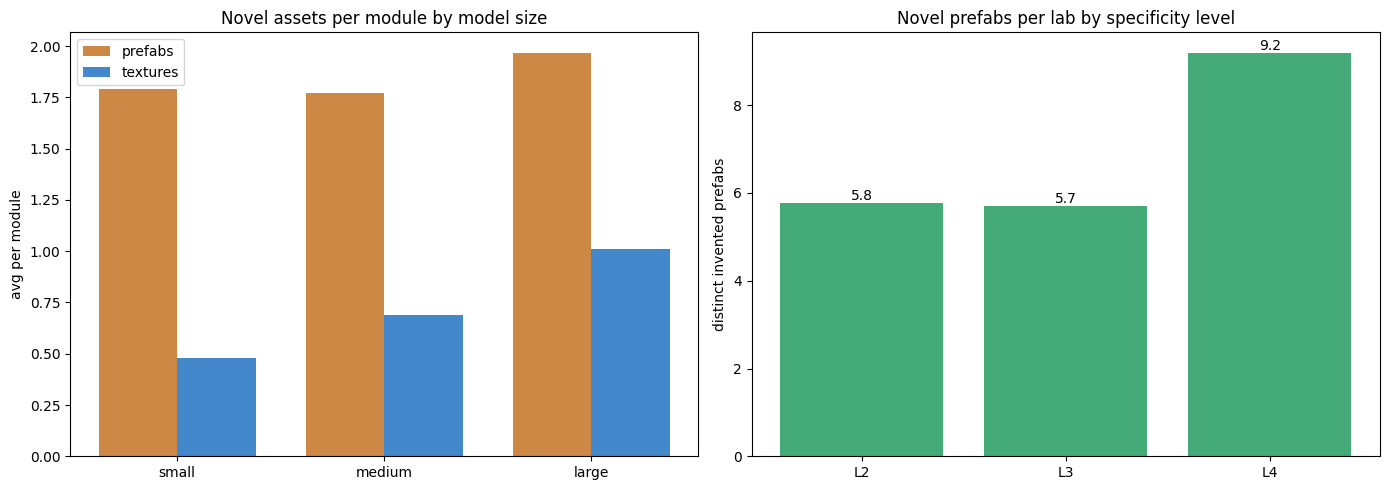

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Novel prefabs & textures per module by model size
order = ['small', 'medium', 'large']
pm = FULL.groupby('size').novel_prefabs_per_module.mean().reindex(order)
tm = FULL.groupby('size').novel_textures_per_module.mean().reindex(order)
x = np.arange(len(order)); w = 0.38
axes[0].bar(x - w/2, pm.values, w, label='prefabs', color='#c84')
axes[0].bar(x + w/2, tm.values, w, label='textures', color='#48c')
axes[0].set_xticks(x); axes[0].set_xticklabels(order)
axes[0].set_title('Novel assets per module by model size')
axes[0].set_ylabel('avg per module'); axes[0].legend()

# Novel prefabs per lab by specificity level
lv = ['L2', 'L3', 'L4']
k = FULL.groupby('level').novel_prefabs.mean().reindex(lv)
axes[1].bar(lv, k.values, color='#4a7')
axes[1].set_title('Novel prefabs per lab by specificity level')
axes[1].set_ylabel('distinct invented prefabs')
for i, v in enumerate(k.values):
    axes[1].annotate(f'{v:.1f}', (i, v), ha='center', va='bottom')

plt.tight_layout(); plt.show()

## Failed runs

Failures live only in the `suite_results_*.json` sweeps (a successful run also writes a standalone metrics file; a failed one does not). They split cleanly into two kinds, keyed on whether the run actually reached the model and burned tokens (`had_usage`):

- **Billable failures** — `truncation (max_tokens)` and `schema validation` retries generated real output before failing, so they carry meaningful token / cost / time stats (and are often *more* expensive than a success, because instructor retried).
- **No-op failures** — `404 model-not-found` and config errors never reached the model: 0 tokens, $0, sub-second. They have no relevant statistics and are excluded from the cost/token aggregates below.

In [10]:
# Overview: how common is each failure mode, and is it billable?
ov = FAIL.groupby('fail_mode').agg(
    failed_runs=('model', 'size'),
    billable=('had_usage', 'sum'),
    total_tokens=('total_tokens', 'sum'),
    total_cost_usd=('effective_cost_usd', 'sum'),
    avg_wall_s=('wall_s', 'mean'),
).round({'total_cost_usd': 2, 'avg_wall_s': 1}).sort_values('failed_runs', ascending=False)
print('Failure modes (the "common errors" breakdown):')
display(ov)
wasted = FAIL.effective_cost_usd.sum(); spent = OK.effective_cost_usd.sum()
print(f'Spend on failed runs: ${wasted:.2f}  ({wasted / (wasted + spent):.1%} of total ${wasted + spent:.2f}) — all from billable failures.')

Failure modes (the "common errors" breakdown):

,failed_runs,billable,total_tokens,total_cost_usd,avg_wall_s
fail_mode,,,,,
schema validation,24,24,2296090,6.22,297.4
truncation (max_tokens),6,6,836610,8.01,235.5
404 model-not-found,4,0,0,0.00,0.6
other,1,0,0,0.00,0.1


Spend on failed runs: $14.24  (45.5% of total $31.28) — all from billable failures.


### Billable failures — what they cost

Token/cost/time for the failures that actually did work, by model. These are the runs worth attention: real money spent on output that didn't validate or got truncated.

In [11]:
BILL = FAIL[FAIL.had_usage]
by_model = BILL.groupby('display_name').agg(
    failed_runs=('model', 'size'),
    total_tokens=('total_tokens', 'sum'),
    total_cost_usd=('effective_cost_usd', 'sum'),
    avg_wall_s=('wall_s', 'mean'),
    avg_retries=('retries', 'mean'),
).round({'total_cost_usd': 3, 'avg_wall_s': 1, 'avg_retries': 1})
display(by_model.sort_values('total_cost_usd', ascending=False))
print('By level:')
display(BILL.groupby('level').agg(
    failed_runs=('model', 'size'),
    avg_tokens=('total_tokens', 'mean'),
    avg_cost_usd=('effective_cost_usd', 'mean'),
    avg_wall_s=('wall_s', 'mean'),
).round(2))

,failed_runs,total_tokens,total_cost_usd,avg_wall_s,avg_retries
display_name,,,,,
GPT-5.5,3,584235,5.537,433.0,5.0
Claude Sonnet 4.6,3,419535,3.913,295.5,5.0
Claude Opus 4.8,2,268062,3.656,192.3,5.0
Claude Haiku 4.5,1,149013,0.444,141.7,5.0
GPT-5.4 Mini,3,208433,0.291,258.5,5.0
GPT-5 Mini,7,789739,0.192,262.1,5.0
GPT-5 Nano,5,357992,0.091,534.1,5.0
GPT-5.4 Nano,2,230097,0.084,134.1,5.0
GPT-4o Mini,4,125594,0.028,72.2,5.0


By level:


,failed_runs,avg_tokens,avg_cost_usd,avg_wall_s
level,,,,
L2,11,90918.55,0.39,200.82
L3,8,99085.12,0.40,299.79
L4,11,121810.45,0.61,358.40


### No-op failures — no relevant statistics

Listed for completeness; these never billed. (`404` = deprecated/bad model id; `other` = a missing-argument config error.)

In [12]:
NOOP = FAIL[~FAIL.had_usage]
display(NOOP[['display_name', 'level', 'lab_name', 'fail_mode', 'total_tokens', 'effective_cost_usd', 'wall_s']].reset_index(drop=True))

,display_name,level,lab_name,fail_mode,total_tokens,effective_cost_usd,wall_s
0,Claude 3 Haiku (dep. Apr 2026),L1,vsepr_molecular_geometry,404 model-not-found,0,0.0,0.68
1,Claude 3 Haiku (dep. Apr 2026),L2,vsepr_molecular_geometry,404 model-not-found,0,0.0,0.66
2,Claude 3 Haiku (dep. Apr 2026),L3,vsepr_molecular_geometry,404 model-not-found,0,0.0,0.56
3,Claude 3 Haiku (dep. Apr 2026),L4,vsepr_molecular_geometry,404 model-not-found,0,0.0,0.49
4,Claude Haiku 4.5,L4,vsepr_molecular_geometry,other,0,0.0,0.06


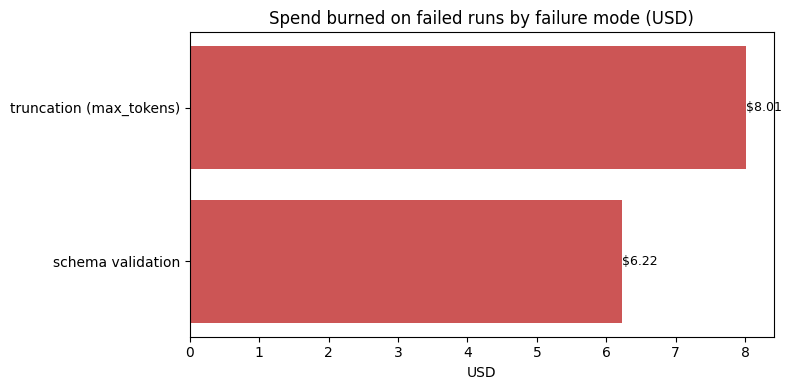

In [13]:
# Cost burned per failure mode (billable only).
fig, ax = plt.subplots(figsize=(8, 4))
fc = BILL.groupby('fail_mode').effective_cost_usd.sum().sort_values()
ax.barh(fc.index, fc.values, color='#c55')
ax.set_title('Spend burned on failed runs by failure mode (USD)')
ax.set_xlabel('USD')
for i, v in enumerate(fc.values):
    ax.annotate(f'${v:.2f}', (v, i), va='center', fontsize=9)
plt.tight_layout(); plt.show()

## Charts

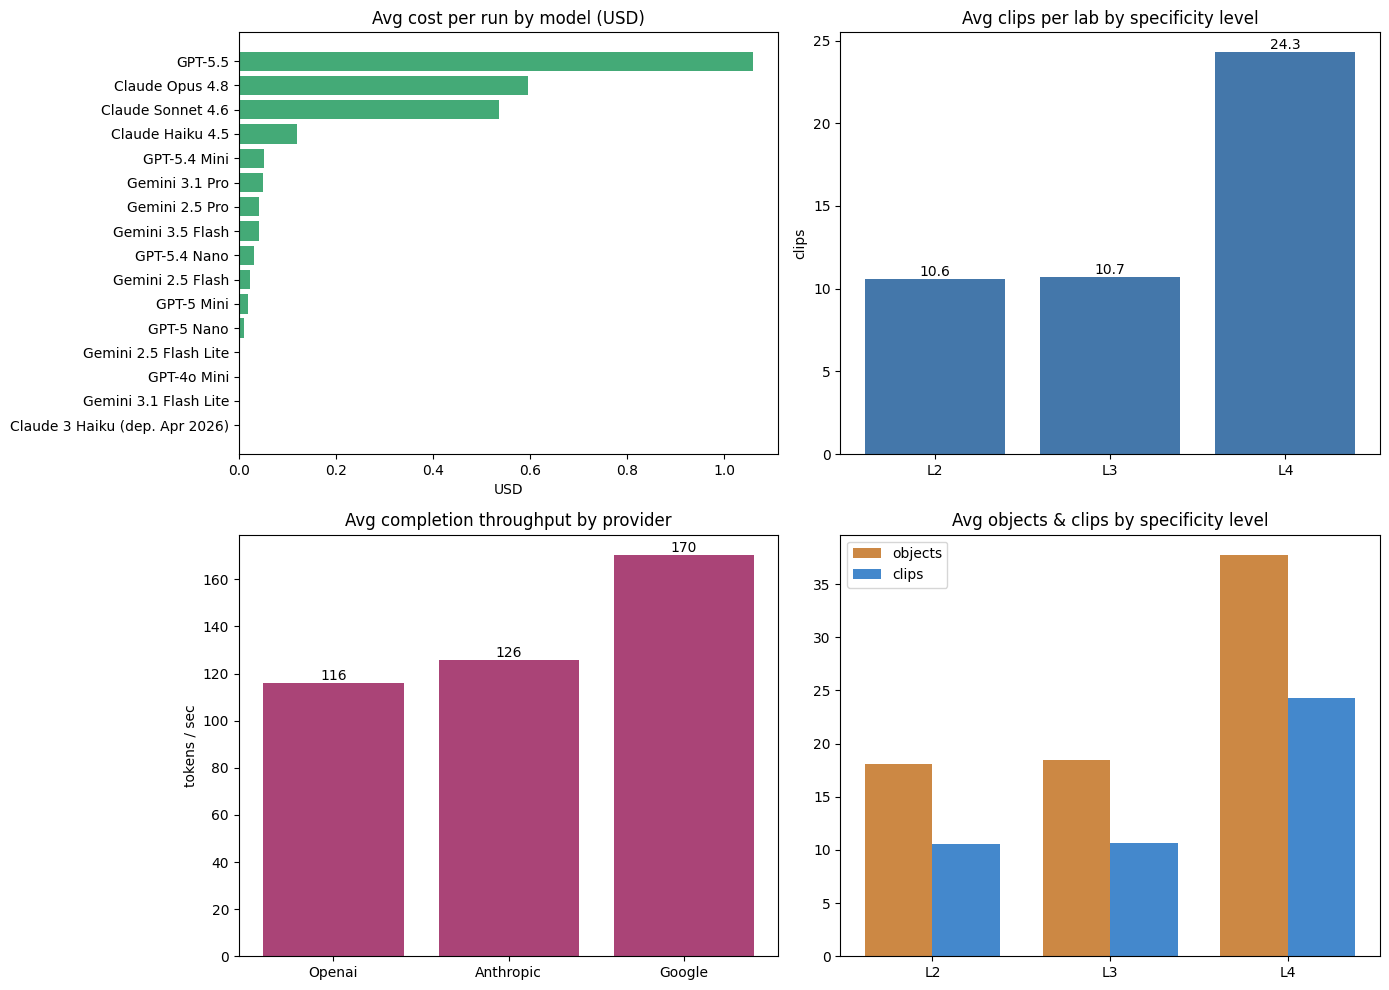

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Avg cost per run by model
c = df.groupby('display_name').effective_cost_usd.mean().sort_values()
axes[0, 0].barh(c.index, c.values, color='#4a7')
axes[0, 0].set_title('Avg cost per run by model (USD)')
axes[0, 0].set_xlabel('USD')

# 2. Avg clips by level (L2-L4)
k = FULL.groupby('level').num_clips.mean().reindex(['L2','L3','L4'])
axes[0, 1].bar(k.index, k.values, color='#47a')
axes[0, 1].set_title('Avg clips per lab by specificity level')
axes[0, 1].set_ylabel('clips')
for i, v in enumerate(k.values):
    axes[0, 1].annotate(f'{v:.1f}', (i, v), ha='center', va='bottom')

# 3. Avg throughput by provider
s = df.groupby('provider').tokens_per_sec.mean().reindex(PROVIDERS)
axes[1, 0].bar([p.capitalize() for p in s.index], s.values, color='#a47')
axes[1, 0].set_title('Avg completion throughput by provider')
axes[1, 0].set_ylabel('tokens / sec')
for i, v in enumerate(s.values):
    axes[1, 0].annotate(f'{v:.0f}', (i, v), ha='center', va='bottom')

# 4. Avg objects vs clips by level
lv = ['L2', 'L3', 'L4']
objs = FULL.groupby('level').num_objects.mean().reindex(lv)
clps = FULL.groupby('level').num_clips.mean().reindex(lv)
x = np.arange(len(lv)); w = 0.38
axes[1, 1].bar(x - w/2, objs.values, w, label='objects', color='#c84')
axes[1, 1].bar(x + w/2, clps.values, w, label='clips', color='#48c')
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(lv)
axes[1, 1].set_title('Avg objects & clips by specificity level')
axes[1, 1].legend()

plt.tight_layout(); plt.show()

## Notes

- Cost/token comparisons across providers use the Gemini-adjusted columns; raw `cost_usd` / `total_tokens` remain in the table if you want the unadjusted figures.
- Structural counts are over **successful** L2–L4 runs only; a model that failed a level contributes no row there.
- Failed-run stats use `had_usage` (`total_tokens > 0`) to separate billable failures from no-op ones; only billable failures enter the cost/token aggregates.
- `num_components` is the count of components created per lab ("new components made"); the per-type breakdown lives in the source metrics' `component_types` if a finer cut is needed.
- Novel-asset counts are computed by re-reading each saved `*_output.json` at load time (no re-running of the sweep); membership in the known moon-lab library is case-insensitive. The invented asset *names* aren't in the CSV but are available per-lab via `lab_metrics.analyze_assets(output_json)` (`novel_prefab_names` / `novel_texture_names`) for qualitative review.